# Step 1: Set Up Python Environment and Project Paths

This step imports the required Python packages and defines the main project folders for saving output tables and figures.

In [2]:
# Step 1.1: Import packages and define project paths

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import simpy

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Define project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

# Create output folders if they do not exist
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Packages imported successfully.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Output tables folder: {OUTPUT_TABLES_DIR}")
print(f"Output figures folder: {OUTPUT_FIGURES_DIR}")

Packages imported successfully.
Project root: /Users/mac/Desktop/portfolio3_operations_simulation
Output tables folder: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/tables
Output figures folder: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures


# Step 2: Define Baseline Warehouse System

This step defines the baseline assumptions for the warehouse order fulfillment simulation, including simulation time, order arrival rate, resource capacity, and processing time distributions.

In [3]:
# Step 2.1: Define baseline warehouse simulation parameters

baseline_params = {
    "scenario_name": "Baseline",
    "simulation_time_minutes": 480,
    "avg_interarrival_time_minutes": 5,
    "num_pickers": 2,
    "num_packers": 1,
    "num_shipping_stations": 1,
    "picking_time_mean": 8,
    "picking_time_sd": 2,
    "packing_time_mean": 6,
    "packing_time_sd": 1.5,
    "shipping_time_mean": 4,
    "shipping_time_sd": 1
}

# Convert baseline parameters into a readable table
baseline_params_df = pd.DataFrame(
    list(baseline_params.items()),
    columns=["Parameter", "Value"]
)

baseline_params_df

,Parameter,Value
0,scenario_name,Baseline
1,simulation_time_minutes,480
2,avg_interarrival_time_minutes,5
3,num_pickers,2
4,num_packers,1
5,num_shipping_stations,1
6,picking_time_mean,8
7,picking_time_sd,2
8,packing_time_mean,6
9,packing_time_sd,1.5


# Step 3: Build a Single-Run Warehouse Simulation Model

This step builds a single-run discrete-event simulation model for the warehouse order fulfillment process. Each order goes through picking, packing, and shipping before completion.

In [4]:
# Step 3.1: Define a helper function for positive processing times

def generate_positive_processing_time(rng, mean, sd):
    """
    Generate a positive processing time using a normal distribution.
    If the sampled value is too small or negative, set it to a small positive value.
    """
    processing_time = rng.normal(loc=mean, scale=sd)
    return max(processing_time, 0.1)

In [5]:
# Step 3.2: Define a single-run warehouse simulation model

def run_single_simulation(params, seed=42):
    """
    Run one simulation of the warehouse order fulfillment system.
    The process includes order arrival, picking, packing, and shipping.
    """
    rng = np.random.default_rng(seed)
    env = simpy.Environment()

    # Create warehouse resources
    pickers = simpy.Resource(env, capacity=params["num_pickers"])
    packers = simpy.Resource(env, capacity=params["num_packers"])
    shipping_stations = simpy.Resource(env, capacity=params["num_shipping_stations"])

    # Store order-level records
    order_records = []

    def order_fulfillment_process(order_id):
        """
        Simulate one order moving through picking, packing, and shipping.
        """
        arrival_time = env.now

        # Picking process
        with pickers.request() as request:
            yield request
            picking_start_time = env.now
            wait_for_picking = picking_start_time - arrival_time

            picking_duration = generate_positive_processing_time(
                rng,
                params["picking_time_mean"],
                params["picking_time_sd"]
            )
            yield env.timeout(picking_duration)
            picking_end_time = env.now

        # Packing process
        with packers.request() as request:
            yield request
            packing_start_time = env.now
            wait_for_packing = packing_start_time - picking_end_time

            packing_duration = generate_positive_processing_time(
                rng,
                params["packing_time_mean"],
                params["packing_time_sd"]
            )
            yield env.timeout(packing_duration)
            packing_end_time = env.now

        # Shipping process
        with shipping_stations.request() as request:
            yield request
            shipping_start_time = env.now
            wait_for_shipping = shipping_start_time - packing_end_time

            shipping_duration = generate_positive_processing_time(
                rng,
                params["shipping_time_mean"],
                params["shipping_time_sd"]
            )
            yield env.timeout(shipping_duration)
            shipping_end_time = env.now

        # Record completed order information
        completion_time = shipping_end_time - arrival_time
        total_waiting_time = wait_for_picking + wait_for_packing + wait_for_shipping

        order_records.append({
            "order_id": order_id,
            "arrival_time": arrival_time,
            "wait_for_picking": wait_for_picking,
            "picking_duration": picking_duration,
            "wait_for_packing": wait_for_packing,
            "packing_duration": packing_duration,
            "wait_for_shipping": wait_for_shipping,
            "shipping_duration": shipping_duration,
            "total_waiting_time": total_waiting_time,
            "completion_time": completion_time,
            "completion_clock_time": shipping_end_time
        })

    def order_arrival_process():
        """
        Generate orders until the simulation time ends.
        """
        order_id = 0

        while env.now < params["simulation_time_minutes"]:
            order_id += 1
            env.process(order_fulfillment_process(order_id))

            interarrival_time = rng.exponential(
                scale=params["avg_interarrival_time_minutes"]
            )
            yield env.timeout(interarrival_time)

    # Start arrival process and run simulation
    env.process(order_arrival_process())
    env.run(until=params["simulation_time_minutes"])

    # Convert order records into a DataFrame
    order_results_df = pd.DataFrame(order_records)

    return order_results_df

In [6]:
# Step 3.3: Run one baseline simulation and inspect order-level results

single_run_results = run_single_simulation(
    params=baseline_params,
    seed=RANDOM_SEED
)

print(f"Number of completed orders: {len(single_run_results)}")
print(f"Number of columns: {single_run_results.shape[1]}")

single_run_results.head(10)

Number of completed orders: 75
Number of columns: 11


,order_id,arrival_time,wait_for_picking,picking_duration,wait_for_packing,packing_duration,wait_for_shipping,shipping_duration,total_waiting_time,completion_time,completion_clock_time
0,1,0.000000,0.000000,5.920032,0.000000,7.125677,0.0,2.697820,0.000000,15.743529,15.743529
1,2,12.021043,0.000000,4.097930,0.000000,5.974798,0.0,4.777792,0.000000,14.850520,26.871563
2,3,13.420014,0.000000,7.367515,1.306242,6.099046,0.0,4.368751,1.306242,19.141553,32.561568
3,4,20.469818,0.000000,9.758796,0.000000,5.925111,0.0,3.571672,0.000000,19.255579,39.725397
4,5,25.702622,0.000000,8.935019,1.516084,5.471800,0.0,4.365444,1.516084,20.288347,45.990969
5,6,27.637096,2.591518,7.630275,3.766636,6.619099,0.0,3.186227,6.358153,23.793755,51.430851
6,7,28.405963,6.231678,10.445083,3.161900,6.923969,0.0,3.175519,9.393578,29.938149,58.344112
7,8,29.981859,7.877031,9.064618,8.245085,6.975889,0.0,4.232161,16.122116,36.394785,66.376643
8,10,35.605737,11.317771,6.975515,8.245460,6.175029,0.0,2.542844,19.563231,35.256618,70.862355
9,9,34.487855,10.594869,12.283295,10.953492,5.520493,0.0,3.361122,21.548360,42.713271,77.201126


# Step 4: Calculate Baseline Performance Metrics

This step summarizes the single-run simulation results into system-level performance metrics, including waiting time, completion time, throughput, and resource utilization.

In [7]:
# Step 4.1: Define a function to calculate performance metrics

def calculate_performance_metrics(order_results_df, params):
    """
    Calculate system-level performance metrics from order-level simulation results.
    """
    throughput = len(order_results_df)

    avg_wait_for_picking = order_results_df["wait_for_picking"].mean()
    avg_wait_for_packing = order_results_df["wait_for_packing"].mean()
    avg_wait_for_shipping = order_results_df["wait_for_shipping"].mean()
    avg_total_waiting_time = order_results_df["total_waiting_time"].mean()
    avg_completion_time = order_results_df["completion_time"].mean()

    # Approximate resource utilization based on completed orders
    picker_utilization = (
        order_results_df["picking_duration"].sum()
        / (params["num_pickers"] * params["simulation_time_minutes"])
    )

    packer_utilization = (
        order_results_df["packing_duration"].sum()
        / (params["num_packers"] * params["simulation_time_minutes"])
    )

    shipping_utilization = (
        order_results_df["shipping_duration"].sum()
        / (params["num_shipping_stations"] * params["simulation_time_minutes"])
    )

    metrics = {
        "scenario_name": params["scenario_name"],
        "throughput": throughput,
        "avg_wait_for_picking": avg_wait_for_picking,
        "avg_wait_for_packing": avg_wait_for_packing,
        "avg_wait_for_shipping": avg_wait_for_shipping,
        "avg_total_waiting_time": avg_total_waiting_time,
        "avg_completion_time": avg_completion_time,
        "picker_utilization": picker_utilization,
        "packer_utilization": packer_utilization,
        "shipping_utilization": shipping_utilization
    }

    return pd.DataFrame([metrics])

In [8]:
# Step 4.2: Calculate baseline performance metrics

baseline_metrics_df = calculate_performance_metrics(
    order_results_df=single_run_results,
    params=baseline_params
)

baseline_metrics_df

,scenario_name,throughput,avg_wait_for_picking,avg_wait_for_packing,avg_wait_for_shipping,avg_total_waiting_time,avg_completion_time,picker_utilization,packer_utilization,shipping_utilization
0,Baseline,75,15.40716,60.27398,0.041672,75.722812,93.762234,0.633777,0.964588,0.586517


# Step 5: Run Multiple Replications for the Baseline Scenario

This step runs the baseline warehouse simulation multiple times with different random seeds. Multiple replications reduce the influence of randomness and provide more stable performance estimates.

In [9]:
# Step 5.1: Run multiple replications for the baseline scenario

def run_multiple_replications(params, num_replications=30, base_seed=42):
    """
    Run multiple simulation replications for one scenario.
    Each replication uses a different random seed.
    """
    replication_metrics = []

    for replication_id in range(1, num_replications + 1):
        seed = base_seed + replication_id

        # Run one simulation replication
        order_results_df = run_single_simulation(
            params=params,
            seed=seed
        )

        # Calculate performance metrics for this replication
        metrics_df = calculate_performance_metrics(
            order_results_df=order_results_df,
            params=params
        )

        # Add replication information
        metrics_df["replication_id"] = replication_id
        metrics_df["seed"] = seed

        replication_metrics.append(metrics_df)

    # Combine all replication results into one table
    replications_df = pd.concat(replication_metrics, ignore_index=True)

    return replications_df


baseline_replications_df = run_multiple_replications(
    params=baseline_params,
    num_replications=30,
    base_seed=RANDOM_SEED
)

print(f"Number of replications: {baseline_replications_df.shape[0]}")

baseline_replications_df.head()

Number of replications: 30


,scenario_name,throughput,avg_wait_for_picking,avg_wait_for_packing,avg_wait_for_shipping,avg_total_waiting_time,avg_completion_time,picker_utilization,packer_utilization,shipping_utilization,replication_id,seed
0,Baseline,70,4.538521,31.215483,0.204710,35.958714,54.058387,0.566738,0.902983,0.603076,1,43
1,Baseline,72,2.763884,12.257838,0.211917,15.233640,33.432449,0.608456,0.929599,0.583310,2,44
2,Baseline,77,8.935014,55.465916,0.146821,64.547750,82.596752,0.639615,0.971471,0.644660,3,45
3,Baseline,80,17.039057,63.031684,0.247258,80.317999,98.375475,0.690080,0.957294,0.672125,4,46
4,Baseline,75,4.098860,20.635078,0.145384,24.879321,42.798923,0.629471,0.924118,0.616879,5,47


In [10]:
# Step 5.2: Summarize baseline replication results

metric_columns = [
    "throughput",
    "avg_wait_for_picking",
    "avg_wait_for_packing",
    "avg_wait_for_shipping",
    "avg_total_waiting_time",
    "avg_completion_time",
    "picker_utilization",
    "packer_utilization",
    "shipping_utilization"
]

baseline_summary_df = baseline_replications_df[metric_columns].agg(
    ["mean", "std"]
).T.reset_index()

baseline_summary_df.columns = ["metric", "mean", "std"]

baseline_summary_df

,metric,mean,std
0,throughput,75.266667,3.139661
1,avg_wait_for_picking,7.406614,5.394511
2,avg_wait_for_packing,42.093320,21.240458
3,avg_wait_for_shipping,0.179582,0.116669
4,avg_total_waiting_time,49.679516,25.605080
5,avg_completion_time,67.781201,25.605162
6,picker_utilization,0.631050,0.036142
7,packer_utilization,0.947111,0.030908
8,shipping_utilization,0.628981,0.034442


# Step 6: Build Scenario Analysis Framework

This step defines the scenario configuration table for comparing different staffing and capacity policies in the warehouse order fulfillment system.

In [11]:
# Step 6.1: Define scenario configurations

scenarios = [
    {
        "scenario_name": "Baseline",
        "simulation_time_minutes": 480,
        "avg_interarrival_time_minutes": 5,
        "num_pickers": 2,
        "num_packers": 1,
        "num_shipping_stations": 1,
        "picking_time_mean": 8,
        "picking_time_sd": 2,
        "packing_time_mean": 6,
        "packing_time_sd": 1.5,
        "shipping_time_mean": 4,
        "shipping_time_sd": 1
    },
    {
        "scenario_name": "Add One Picker",
        "simulation_time_minutes": 480,
        "avg_interarrival_time_minutes": 5,
        "num_pickers": 3,
        "num_packers": 1,
        "num_shipping_stations": 1,
        "picking_time_mean": 8,
        "picking_time_sd": 2,
        "packing_time_mean": 6,
        "packing_time_sd": 1.5,
        "shipping_time_mean": 4,
        "shipping_time_sd": 1
    },
    {
        "scenario_name": "Add One Packer",
        "simulation_time_minutes": 480,
        "avg_interarrival_time_minutes": 5,
        "num_pickers": 2,
        "num_packers": 2,
        "num_shipping_stations": 1,
        "picking_time_mean": 8,
        "picking_time_sd": 2,
        "packing_time_mean": 6,
        "packing_time_sd": 1.5,
        "shipping_time_mean": 4,
        "shipping_time_sd": 1
    },
    {
        "scenario_name": "Add One Shipping Station",
        "simulation_time_minutes": 480,
        "avg_interarrival_time_minutes": 5,
        "num_pickers": 2,
        "num_packers": 1,
        "num_shipping_stations": 2,
        "picking_time_mean": 8,
        "picking_time_sd": 2,
        "packing_time_mean": 6,
        "packing_time_sd": 1.5,
        "shipping_time_mean": 4,
        "shipping_time_sd": 1
    },
    {
        "scenario_name": "Balanced Capacity",
        "simulation_time_minutes": 480,
        "avg_interarrival_time_minutes": 5,
        "num_pickers": 3,
        "num_packers": 2,
        "num_shipping_stations": 1,
        "picking_time_mean": 8,
        "picking_time_sd": 2,
        "packing_time_mean": 6,
        "packing_time_sd": 1.5,
        "shipping_time_mean": 4,
        "shipping_time_sd": 1
    }
]

# Convert scenario configurations into a DataFrame
scenarios_df = pd.DataFrame(scenarios)

scenarios_df

,scenario_name,simulation_time_minutes,avg_interarrival_time_minutes,num_pickers,num_packers,num_shipping_stations,picking_time_mean,picking_time_sd,packing_time_mean,packing_time_sd,shipping_time_mean,shipping_time_sd
0,Baseline,480,5,2,1,1,8,2,6,1.5,4,1
1,Add One Picker,480,5,3,1,1,8,2,6,1.5,4,1
2,Add One Packer,480,5,2,2,1,8,2,6,1.5,4,1
3,Add One Shipping Station,480,5,2,1,2,8,2,6,1.5,4,1
4,Balanced Capacity,480,5,3,2,1,8,2,6,1.5,4,1


# Step 7: Run All Scenarios

This step runs 30 replications for each scenario and summarizes the average performance of each staffing and capacity policy.

In [12]:
# Step 7.1: Run multiple replications for all scenarios

all_scenario_replications = []

for _, scenario_row in scenarios_df.iterrows():
    # Convert each scenario row into a parameter dictionary
    scenario_params = scenario_row.to_dict()
    
    # Run 30 replications for this scenario
    scenario_replications_df = run_multiple_replications(
        params=scenario_params,
        num_replications=30,
        base_seed=RANDOM_SEED
    )
    
    all_scenario_replications.append(scenario_replications_df)

# Combine all scenario replication results
all_scenario_replications_df = pd.concat(
    all_scenario_replications,
    ignore_index=True
)

print(f"Number of scenario replications: {all_scenario_replications_df.shape[0]}")
print(f"Number of scenarios: {all_scenario_replications_df['scenario_name'].nunique()}")

all_scenario_replications_df.head()

Number of scenario replications: 150
Number of scenarios: 5


,scenario_name,throughput,avg_wait_for_picking,avg_wait_for_packing,avg_wait_for_shipping,avg_total_waiting_time,avg_completion_time,picker_utilization,packer_utilization,shipping_utilization,replication_id,seed
0,Baseline,70,4.538521,31.215483,0.204710,35.958714,54.058387,0.566738,0.902983,0.603076,1,43
1,Baseline,72,2.763884,12.257838,0.211917,15.233640,33.432449,0.608456,0.929599,0.583310,2,44
2,Baseline,77,8.935014,55.465916,0.146821,64.547750,82.596752,0.639615,0.971471,0.644660,3,45
3,Baseline,80,17.039057,63.031684,0.247258,80.317999,98.375475,0.690080,0.957294,0.672125,4,46
4,Baseline,75,4.098860,20.635078,0.145384,24.879321,42.798923,0.629471,0.924118,0.616879,5,47


In [13]:
# Step 7.2: Summarize scenario comparison results

scenario_summary_df = (
    all_scenario_replications_df
    .groupby("scenario_name")[metric_columns]
    .agg(["mean", "std"])
)

# Flatten multi-level column names
scenario_summary_df.columns = [
    f"{metric}_{stat}" for metric, stat in scenario_summary_df.columns
]

scenario_summary_df = scenario_summary_df.reset_index()

# Add scenario resource configuration columns
scenario_config_cols = [
    "scenario_name",
    "num_pickers",
    "num_packers",
    "num_shipping_stations",
    "avg_interarrival_time_minutes"
]

scenario_summary_df = scenarios_df[scenario_config_cols].merge(
    scenario_summary_df,
    on="scenario_name",
    how="left"
)

scenario_summary_df

,scenario_name,num_pickers,num_packers,num_shipping_stations,avg_interarrival_time_minutes,throughput_mean,throughput_std,avg_wait_for_picking_mean,avg_wait_for_picking_std,avg_wait_for_packing_mean,...,avg_total_waiting_time_mean,avg_total_waiting_time_std,avg_completion_time_mean,avg_completion_time_std,picker_utilization_mean,picker_utilization_std,packer_utilization_mean,packer_utilization_std,shipping_utilization_mean,shipping_utilization_std
0,Baseline,2,1,1,5,75.266667,3.139661,7.406614,5.394511,42.093320,...,49.679516,25.605080,67.781201,25.605162,0.631050,0.036142,0.947111,0.030908,0.628981,0.034442
1,Add One Picker,3,1,1,5,76.133333,2.192988,0.918382,0.578126,48.166476,...,49.253468,20.604598,67.347424,20.662589,0.426703,0.015573,0.951310,0.019526,0.638009,0.025746
2,Add One Packer,2,2,1,5,91.233333,8.274111,5.307420,2.667708,0.212331,...,8.642685,3.535787,26.715600,3.567998,0.762637,0.075239,0.572624,0.052389,0.764456,0.065882
3,Add One Shipping Station,2,1,2,5,75.533333,3.569346,7.530532,5.387257,44.833060,...,52.363592,23.120286,70.447584,23.045475,0.631915,0.035485,0.947387,0.036317,0.316971,0.017315
4,Balanced Capacity,3,2,1,5,92.733333,8.978646,0.804268,0.465536,0.965550,...,6.737035,3.028635,24.755359,3.048724,0.519803,0.054251,0.575054,0.061940,0.772305,0.072869


In [14]:
# Step 7.3: Save scenario summary table

scenario_summary_path = OUTPUT_TABLES_DIR / "scenario_summary.csv"

scenario_summary_df.to_csv(
    scenario_summary_path,
    index=False
)

print(f"Scenario summary saved to: {scenario_summary_path}")

Scenario summary saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/tables/scenario_summary.csv


# Step 8: Bottleneck Analysis

This step identifies the most likely bottleneck in each scenario based on resource utilization and waiting time by process stage.

In [15]:
# Step 8.1: Create a simplified scenario comparison table

key_metric_columns = [
    "scenario_name",
    "num_pickers",
    "num_packers",
    "num_shipping_stations",
    "throughput_mean",
    "avg_wait_for_picking_mean",
    "avg_wait_for_packing_mean",
    "avg_wait_for_shipping_mean",
    "avg_total_waiting_time_mean",
    "avg_completion_time_mean",
    "picker_utilization_mean",
    "packer_utilization_mean",
    "shipping_utilization_mean"
]

scenario_key_metrics_df = scenario_summary_df[key_metric_columns].copy()

scenario_key_metrics_df

,scenario_name,num_pickers,num_packers,num_shipping_stations,throughput_mean,avg_wait_for_picking_mean,avg_wait_for_packing_mean,avg_wait_for_shipping_mean,avg_total_waiting_time_mean,avg_completion_time_mean,picker_utilization_mean,packer_utilization_mean,shipping_utilization_mean
0,Baseline,2,1,1,75.266667,7.406614,42.093320,0.179582,49.679516,67.781201,0.631050,0.947111,0.628981
1,Add One Picker,3,1,1,76.133333,0.918382,48.166476,0.168609,49.253468,67.347424,0.426703,0.951310,0.638009
2,Add One Packer,2,2,1,91.233333,5.307420,0.212331,3.122933,8.642685,26.715600,0.762637,0.572624,0.764456
3,Add One Shipping Station,2,1,2,75.533333,7.530532,44.833060,0.000000,52.363592,70.447584,0.631915,0.947387,0.316971
4,Balanced Capacity,3,2,1,92.733333,0.804268,0.965550,4.967217,6.737035,24.755359,0.519803,0.575054,0.772305


In [16]:
# Step 8.2: Identify bottlenecks based on utilization and waiting time

def identify_bottleneck(row):
    """
    Identify the bottleneck resource and longest waiting stage for one scenario.
    """
    utilization_values = {
        "Picker": row["picker_utilization_mean"],
        "Packer": row["packer_utilization_mean"],
        "Shipping Station": row["shipping_utilization_mean"]
    }

    waiting_values = {
        "Picking": row["avg_wait_for_picking_mean"],
        "Packing": row["avg_wait_for_packing_mean"],
        "Shipping": row["avg_wait_for_shipping_mean"]
    }

    max_utilization_resource = max(utilization_values, key=utilization_values.get)
    max_utilization_value = utilization_values[max_utilization_resource]

    longest_wait_stage = max(waiting_values, key=waiting_values.get)
    longest_wait_minutes = waiting_values[longest_wait_stage]

    return pd.Series({
        "max_utilization_resource": max_utilization_resource,
        "max_utilization_value": max_utilization_value,
        "longest_wait_stage": longest_wait_stage,
        "longest_wait_minutes": longest_wait_minutes
    })


bottleneck_summary_df = scenario_key_metrics_df.copy()

bottleneck_summary_df = pd.concat(
    [
        bottleneck_summary_df,
        bottleneck_summary_df.apply(identify_bottleneck, axis=1)
    ],
    axis=1
)

bottleneck_summary_df[
    [
        "scenario_name",
        "max_utilization_resource",
        "max_utilization_value",
        "longest_wait_stage",
        "longest_wait_minutes"
    ]
]

,scenario_name,max_utilization_resource,max_utilization_value,longest_wait_stage,longest_wait_minutes
0,Baseline,Packer,0.947111,Packing,42.093320
1,Add One Picker,Packer,0.951310,Packing,48.166476
2,Add One Packer,Shipping Station,0.764456,Picking,5.307420
3,Add One Shipping Station,Packer,0.947387,Packing,44.833060
4,Balanced Capacity,Shipping Station,0.772305,Shipping,4.967217


In [17]:
# Step 8.3: Calculate improvement compared with the baseline scenario

baseline_row = scenario_key_metrics_df[
    scenario_key_metrics_df["scenario_name"] == "Baseline"
].iloc[0]

bottleneck_summary_df["throughput_change_vs_baseline"] = (
    bottleneck_summary_df["throughput_mean"]
    - baseline_row["throughput_mean"]
)

bottleneck_summary_df["waiting_time_reduction_pct_vs_baseline"] = (
    (
        baseline_row["avg_total_waiting_time_mean"]
        - bottleneck_summary_df["avg_total_waiting_time_mean"]
    )
    / baseline_row["avg_total_waiting_time_mean"]
    * 100
)

bottleneck_summary_df["completion_time_reduction_pct_vs_baseline"] = (
    (
        baseline_row["avg_completion_time_mean"]
        - bottleneck_summary_df["avg_completion_time_mean"]
    )
    / baseline_row["avg_completion_time_mean"]
    * 100
)

bottleneck_summary_df[
    [
        "scenario_name",
        "throughput_mean",
        "throughput_change_vs_baseline",
        "avg_total_waiting_time_mean",
        "waiting_time_reduction_pct_vs_baseline",
        "avg_completion_time_mean",
        "completion_time_reduction_pct_vs_baseline"
    ]
]

,scenario_name,throughput_mean,throughput_change_vs_baseline,avg_total_waiting_time_mean,waiting_time_reduction_pct_vs_baseline,avg_completion_time_mean,completion_time_reduction_pct_vs_baseline
0,Baseline,75.266667,0.000000,49.679516,0.000000,67.781201,0.000000
1,Add One Picker,76.133333,0.866667,49.253468,0.857594,67.347424,0.639967
2,Add One Packer,91.233333,15.966667,8.642685,82.603122,26.715600,60.585532
3,Add One Shipping Station,75.533333,0.266667,52.363592,-5.402782,70.447584,-3.933809
4,Balanced Capacity,92.733333,17.466667,6.737035,86.439009,24.755359,63.477545


In [18]:
# Step 8.4: Save bottleneck analysis table

bottleneck_summary_path = OUTPUT_TABLES_DIR / "bottleneck_summary.csv"

bottleneck_summary_df.to_csv(
    bottleneck_summary_path,
    index=False
)

print(f"Bottleneck summary saved to: {bottleneck_summary_path}")

Bottleneck summary saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/tables/bottleneck_summary.csv


# Step 9: Visualization

This step creates and saves key figures in both PDF and PNG formats for comparing scenario performance, including completion time, waiting time, throughput, resource utilization, and waiting time by process stage.

In [19]:
# Step 9.1: Prepare plotting data and define figure saving function

plot_df = scenario_key_metrics_df.copy()

# Keep scenarios in the original scenario design order
scenario_order = scenarios_df["scenario_name"].tolist()
plot_df["scenario_name"] = pd.Categorical(
    plot_df["scenario_name"],
    categories=scenario_order,
    ordered=True
)

plot_df = plot_df.sort_values("scenario_name").reset_index(drop=True)

# Use PDF-friendly font settings
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

def save_figure_both_formats(fig, file_stem):
    """
    Save one figure in both PDF and PNG formats.
    PDF is used for formal reports.
    PNG is used for README and GitHub Pages.
    """
    pdf_path = OUTPUT_FIGURES_DIR / f"{file_stem}.pdf"
    png_path = OUTPUT_FIGURES_DIR / f"{file_stem}.png"
    
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    
    print(f"PDF saved to: {pdf_path}")
    print(f"PNG saved to: {png_path}")


plot_df[
    [
        "scenario_name",
        "throughput_mean",
        "avg_total_waiting_time_mean",
        "avg_completion_time_mean",
        "picker_utilization_mean",
        "packer_utilization_mean",
        "shipping_utilization_mean"
    ]
]

,scenario_name,throughput_mean,avg_total_waiting_time_mean,avg_completion_time_mean,picker_utilization_mean,packer_utilization_mean,shipping_utilization_mean
0,Baseline,75.266667,49.679516,67.781201,0.631050,0.947111,0.628981
1,Add One Picker,76.133333,49.253468,67.347424,0.426703,0.951310,0.638009
2,Add One Packer,91.233333,8.642685,26.715600,0.762637,0.572624,0.764456
3,Add One Shipping Station,75.533333,52.363592,70.447584,0.631915,0.947387,0.316971
4,Balanced Capacity,92.733333,6.737035,24.755359,0.519803,0.575054,0.772305


PDF saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/01_avg_completion_time_by_scenario.pdf
PNG saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/01_avg_completion_time_by_scenario.png


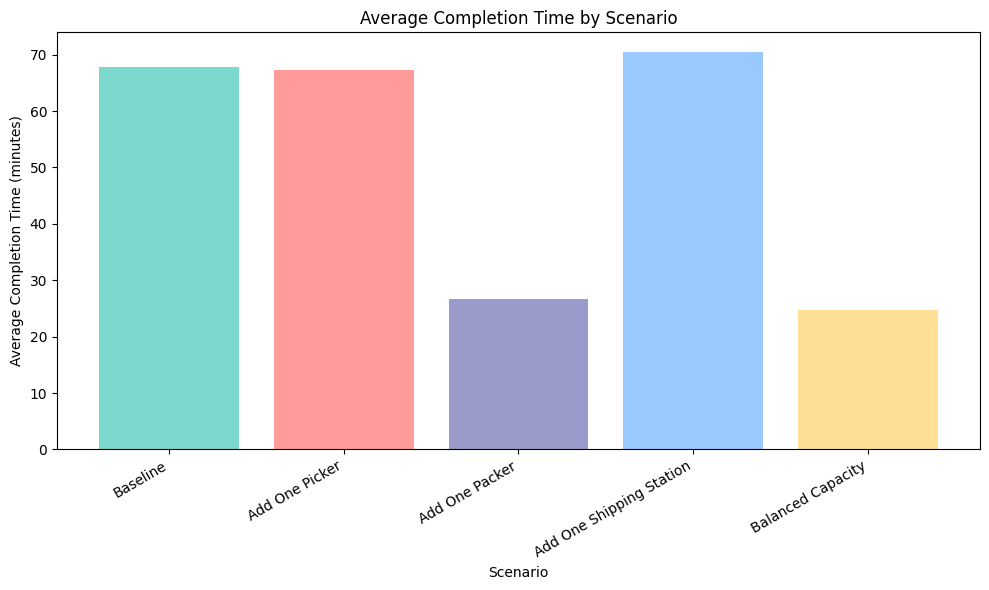

In [20]:
# Step 9.2: Plot average completion time by scenario

# Define the scenario order and assigned colors
scenario_order = [
    "Baseline",
    "Add One Picker",
    "Add One Packer",
    "Add One Shipping Station",
    "Balanced Capacity",
]

scenario_colors = {
    "Baseline": "#7DD8CE",
    "Add One Picker": "#FF9B9A",
    "Add One Packer": "#9A9BCB",
    "Add One Shipping Station": "#9AC9FF",
    "Balanced Capacity": "#FEDF94",
}

# Arrange the data in the required scenario order
completion_plot_df = (
    plot_df
    .set_index("scenario_name")
    .reindex(scenario_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    completion_plot_df["scenario_name"],
    completion_plot_df["avg_completion_time_mean"],
    color=[
        scenario_colors[scenario]
        for scenario in completion_plot_df["scenario_name"]
    ],
)

ax.set_title("Average Completion Time by Scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Average Completion Time (minutes)")
ax.tick_params(axis="x", rotation=30)

plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()

save_figure_both_formats(
    fig=fig,
    file_stem="01_avg_completion_time_by_scenario",
)

plt.show()

PDF saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/02_avg_waiting_time_by_scenario.pdf
PNG saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/02_avg_waiting_time_by_scenario.png


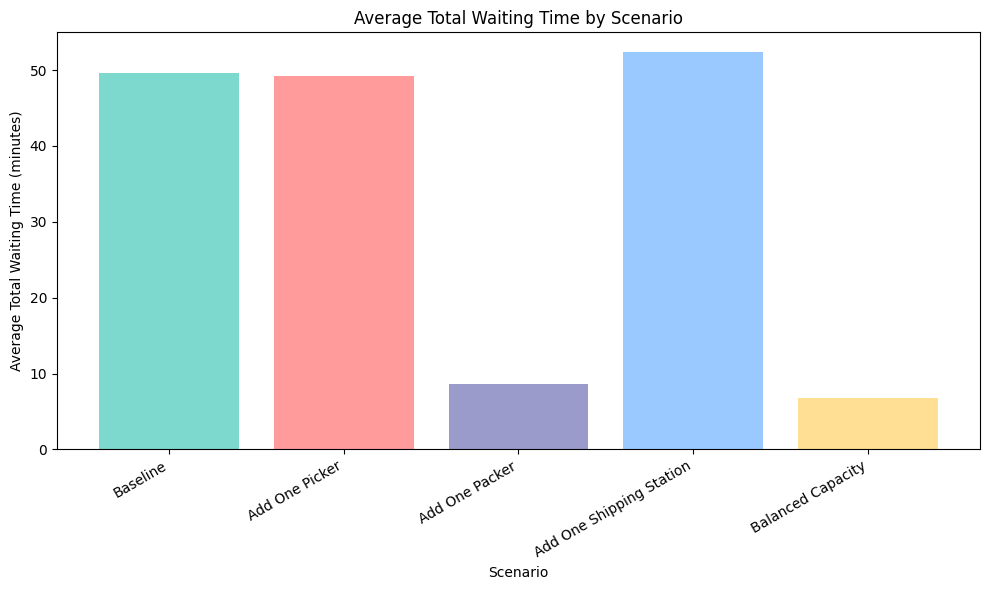

In [21]:
# Step 9.3: Plot average total waiting time by scenario

# Define the scenario order and assigned colors
scenario_order = [
    "Baseline",
    "Add One Picker",
    "Add One Packer",
    "Add One Shipping Station",
    "Balanced Capacity",
]

scenario_colors = {
    "Baseline": "#7DD8CE",
    "Add One Picker": "#FF9B9A",
    "Add One Packer": "#9A9BCB",
    "Add One Shipping Station": "#9AC9FF",
    "Balanced Capacity": "#FEDF94",
}

# Arrange the data in the required scenario order
waiting_plot_df = (
    plot_df
    .set_index("scenario_name")
    .reindex(scenario_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    waiting_plot_df["scenario_name"],
    waiting_plot_df["avg_total_waiting_time_mean"],
    color=[
        scenario_colors[scenario]
        for scenario in waiting_plot_df["scenario_name"]
    ],
)

ax.set_title("Average Total Waiting Time by Scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Average Total Waiting Time (minutes)")
ax.tick_params(axis="x", rotation=30)

plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()

save_figure_both_formats(
    fig=fig,
    file_stem="02_avg_waiting_time_by_scenario",
)

plt.show()

PDF saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/03_throughput_by_scenario.pdf
PNG saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/03_throughput_by_scenario.png


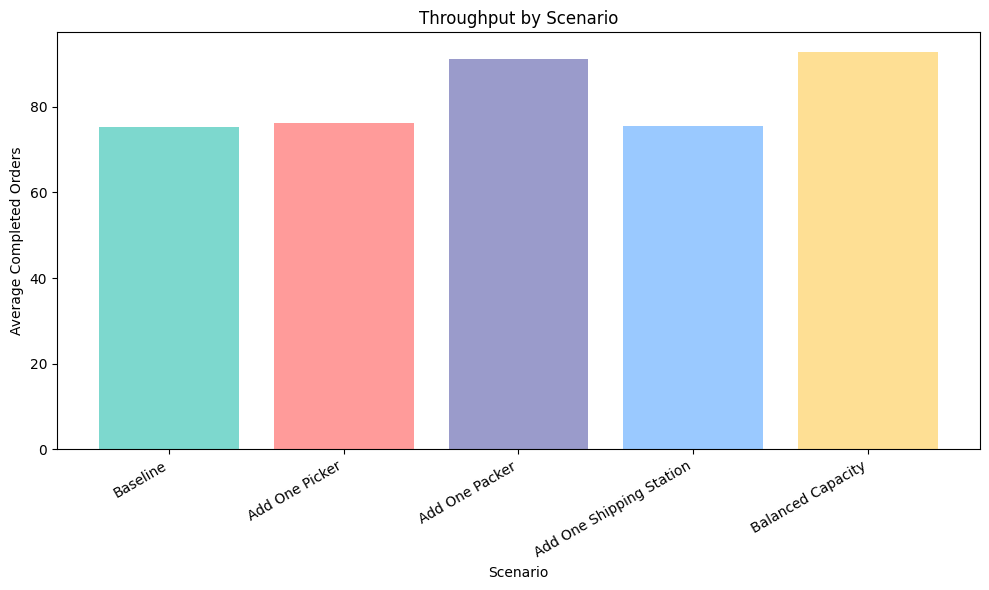

In [22]:
# Step 9.4: Plot throughput by scenario

# Define the scenario order and assigned colors
scenario_order = [
    "Baseline",
    "Add One Picker",
    "Add One Packer",
    "Add One Shipping Station",
    "Balanced Capacity",
]

scenario_colors = {
    "Baseline": "#7DD8CE",
    "Add One Picker": "#FF9B9A",
    "Add One Packer": "#9A9BCB",
    "Add One Shipping Station": "#9AC9FF",
    "Balanced Capacity": "#FEDF94",
}

# Arrange the data in the required scenario order
throughput_plot_df = (
    plot_df
    .set_index("scenario_name")
    .reindex(scenario_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    throughput_plot_df["scenario_name"],
    throughput_plot_df["throughput_mean"],
    color=[
        scenario_colors[scenario]
        for scenario in throughput_plot_df["scenario_name"]
    ],
)

ax.set_title("Throughput by Scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Average Completed Orders")
ax.tick_params(axis="x", rotation=30)

plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()

save_figure_both_formats(
    fig=fig,
    file_stem="03_throughput_by_scenario",
)

plt.show()

PDF saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/04_resource_utilization_by_scenario.pdf
PNG saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/04_resource_utilization_by_scenario.png


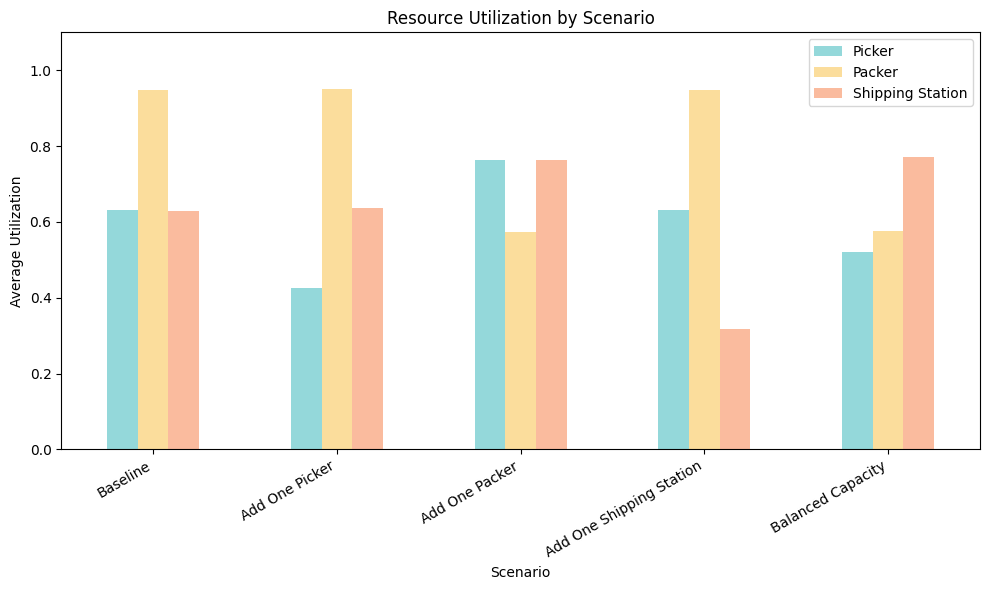

In [23]:
# Step 9.5: Plot resource utilization by scenario

utilization_plot_df = plot_df[
    [
        "scenario_name",
        "picker_utilization_mean",
        "packer_utilization_mean",
        "shipping_utilization_mean"
    ]
].set_index("scenario_name")

resource_colors = [
    "#94D8DA",  # Picker
    "#FBDD9C",  # Packer
    "#FABB9E",  # Shipping Station
]

ax = utilization_plot_df.plot(
    kind="bar",
    figsize=(10, 6),
    color=resource_colors
)

ax.set_title("Resource Utilization by Scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Average Utilization")
ax.set_ylim(0, 1.1)
ax.legend(["Picker", "Packer", "Shipping Station"])
ax.tick_params(axis="x", rotation=30)

plt.setp(ax.get_xticklabels(), ha="right")

fig = ax.get_figure()
fig.tight_layout()

save_figure_both_formats(
    fig=fig,
    file_stem="04_resource_utilization_by_scenario"
)

plt.show()

PDF saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/05_waiting_time_by_stage.pdf
PNG saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/05_waiting_time_by_stage.png


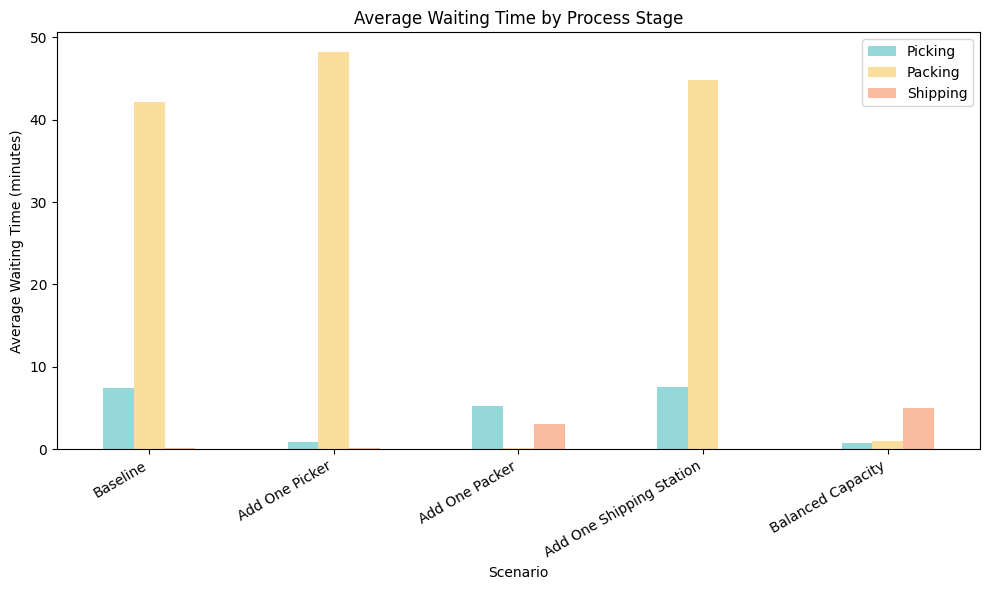

In [24]:
# Step 9.6: Plot waiting time by process stage

scenario_order = [
    "Baseline",
    "Add One Picker",
    "Add One Packer",
    "Add One Shipping Station",
    "Balanced Capacity",
]

waiting_stage_plot_df = (
    plot_df[
        [
            "scenario_name",
            "avg_wait_for_picking_mean",
            "avg_wait_for_packing_mean",
            "avg_wait_for_shipping_mean"
        ]
    ]
    .set_index("scenario_name")
    .reindex(scenario_order)
)

process_colors = [
    "#94D8DA",  # Picking
    "#FBDD9C",  # Packing
    "#FABB9E",  # Shipping
]

ax = waiting_stage_plot_df.plot(
    kind="bar",
    figsize=(10, 6),
    color=process_colors
)

ax.set_title("Average Waiting Time by Process Stage")
ax.set_xlabel("Scenario")
ax.set_ylabel("Average Waiting Time (minutes)")
ax.legend(["Picking", "Packing", "Shipping"])
ax.tick_params(axis="x", rotation=30)

plt.setp(ax.get_xticklabels(), ha="right")

fig = ax.get_figure()
fig.tight_layout()

save_figure_both_formats(
    fig=fig,
    file_stem="05_waiting_time_by_stage"
)

plt.show()

### Interactive Figures for GitHub Pages

In [25]:
# Check the columns used for interactive visualizations

print(plot_df.columns.tolist())

['scenario_name', 'num_pickers', 'num_packers', 'num_shipping_stations', 'throughput_mean', 'avg_wait_for_picking_mean', 'avg_wait_for_packing_mean', 'avg_wait_for_shipping_mean', 'avg_total_waiting_time_mean', 'avg_completion_time_mean', 'picker_utilization_mean', 'packer_utilization_mean', 'shipping_utilization_mean']


In [26]:
# Create the output folder for GitHub Pages interactive figures

from pathlib import Path

project_root = Path.cwd()

# The notebook may be running from the notebooks folder
if project_root.name == "notebooks":
    project_root = project_root.parent

interactive_dir = project_root / "docs" / "interactive"
interactive_dir.mkdir(parents=True, exist_ok=True)

print("Interactive figure directory:")
print(interactive_dir)

Interactive figure directory:
/Users/mac/Desktop/portfolio3_operations_simulation/docs/interactive


In [27]:
# Interactive Figure 4:
# Resource Utilization by Resource Configuration

import plotly.graph_objects as go

scenario_order = [
    "Baseline",
    "Add One Picker",
    "Add One Packer",
    "Add One Shipping Station",
    "Balanced Capacity"
]

figure4_df = (
    plot_df
    .set_index("scenario_name")
    .loc[scenario_order]
    .reset_index()
)

fig4_interactive = go.Figure()

fig4_interactive.add_trace(
    go.Bar(
        name="Picker",
        x=figure4_df["scenario_name"],
        y=figure4_df["picker_utilization_mean"],
        marker_color="#94D8DA",
        customdata=figure4_df["picker_utilization_mean"],
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Resource: Picker<br>"
            "Utilization: %{customdata:.3f}"
            "<extra></extra>"
        )
    )
)

fig4_interactive.add_trace(
    go.Bar(
        name="Packer",
        x=figure4_df["scenario_name"],
        y=figure4_df["packer_utilization_mean"],
        marker_color="#FBDD9C",
        customdata=figure4_df["packer_utilization_mean"],
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Resource: Packer<br>"
            "Utilization: %{customdata:.3f}"
            "<extra></extra>"
        )
    )
)

fig4_interactive.add_trace(
    go.Bar(
        name="Shipping Station",
        x=figure4_df["scenario_name"],
        y=figure4_df["shipping_utilization_mean"],
        marker_color="#FABB9E",
        customdata=figure4_df["shipping_utilization_mean"],
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Resource: Shipping Station<br>"
            "Utilization: %{customdata:.3f}"
            "<extra></extra>"
        )
    )
)

fig4_interactive.update_layout(
    xaxis_title="Resource Configuration",
    yaxis_title="Average Resource Utilization",
    barmode="group",
    hovermode="closest",
    template="plotly_white",
    height=550,
    margin=dict(l=70, r=30, t=30, b=130),
    legend_title_text="Resource",
    font=dict(size=13)
)

fig4_interactive.update_xaxes(
    tickangle=-20
)

fig4_interactive.update_yaxes(
    range=[0, 1.05],
    tickformat=".1f"
)

figure4_html_path = (
    interactive_dir /
    "figure4_resource_utilization.html"
)

fig4_interactive.write_html(
    figure4_html_path,
    include_plotlyjs="cdn",
    full_html=True,
    config={
        "responsive": True,
        "displaylogo": False
    }
)

print("Interactive Figure 4 saved to:")
print(figure4_html_path)

fig4_interactive.show()

Interactive Figure 4 saved to:
/Users/mac/Desktop/portfolio3_operations_simulation/docs/interactive/figure4_resource_utilization.html


In [34]:
# Interactive Figure 5:
# Average Waiting Time by Process Stage and Resource Configuration

figure5_df = (
    plot_df
    .set_index("scenario_name")
    .loc[scenario_order]
    .reset_index()
)

fig5_interactive = go.Figure()

fig5_interactive.add_trace(
    go.Bar(
        name="Picking",
        x=figure5_df["scenario_name"],
        y=figure5_df["avg_wait_for_picking_mean"],
        marker_color="#94D8DA",
        customdata=figure5_df["avg_wait_for_picking_mean"],
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Stage: Picking<br>"
            "Average Waiting Time: %{customdata:.3f} minutes"
            "<extra></extra>"
        )
    )
)

fig5_interactive.add_trace(
    go.Bar(
        name="Packing",
        x=figure5_df["scenario_name"],
        y=figure5_df["avg_wait_for_packing_mean"],
        marker_color="#FBDD9C",
        customdata=figure5_df["avg_wait_for_packing_mean"],
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Stage: Packing<br>"
            "Average Waiting Time: %{customdata:.3f} minutes"
            "<extra></extra>"
        )
    )
)

fig5_interactive.add_trace(
    go.Bar(
        name="Shipping",
        x=figure5_df["scenario_name"],
        y=figure5_df["avg_wait_for_shipping_mean"],
        marker_color="#FABB9E",
        customdata=figure5_df["avg_wait_for_shipping_mean"],
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Stage: Shipping<br>"
            "Average Waiting Time: %{customdata:.3f} minutes"
            "<extra></extra>"
        )
    )
)

fig5_interactive.update_layout(
    xaxis_title="Resource Configuration",
    yaxis_title="Average Waiting Time (minutes)",
    barmode="group",
    hovermode="closest",
    template="plotly_white",
    height=550,
    margin=dict(l=70, r=30, t=30, b=130),
    legend_title_text="Process Stage",
    font=dict(size=13)
)

fig5_interactive.update_xaxes(
    tickangle=-20
)

fig5_interactive.update_yaxes(
    rangemode="tozero"
)

figure5_html_path = (
    interactive_dir /
    "figure5_stage_waiting_time.html"
)

fig5_interactive.write_html(
    figure5_html_path,
    include_plotlyjs="cdn",
    full_html=True,
    config={
        "responsive": True,
        "displaylogo": False
    }
)

print("Interactive Figure 5 saved to:")
print(figure5_html_path)

fig5_interactive.show()

Interactive Figure 5 saved to:
/Users/mac/Desktop/portfolio3_operations_simulation/docs/interactive/figure5_stage_waiting_time.html


In [29]:
# Check the DataFrames used for the remaining interactive figures

import pandas as pd

print("Columns in plot_df:")
print(plot_df.columns.tolist())

print("\nPossible sensitivity-analysis DataFrames:")

for object_name, object_value in list(globals().items()):
    if isinstance(object_value, pd.DataFrame):
        column_names = object_value.columns.tolist()

        has_interarrival_column = any(
            "interarrival" in str(column).lower()
            for column in column_names
        )

        has_sensitivity_metrics = (
            "avg_total_waiting_time_mean" in column_names
            or "throughput_mean" in column_names
        )

        if has_interarrival_column and has_sensitivity_metrics:
            print(f"\nDataFrame name: {object_name}")
            print(f"Shape: {object_value.shape}")
            print(f"Columns: {column_names}")

Columns in plot_df:
['scenario_name', 'num_pickers', 'num_packers', 'num_shipping_stations', 'throughput_mean', 'avg_wait_for_picking_mean', 'avg_wait_for_packing_mean', 'avg_wait_for_shipping_mean', 'avg_total_waiting_time_mean', 'avg_completion_time_mean', 'picker_utilization_mean', 'packer_utilization_mean', 'shipping_utilization_mean']

Possible sensitivity-analysis DataFrames:

DataFrame name: scenario_summary_df
Shape: (5, 23)
Columns: ['scenario_name', 'num_pickers', 'num_packers', 'num_shipping_stations', 'avg_interarrival_time_minutes', 'throughput_mean', 'throughput_std', 'avg_wait_for_picking_mean', 'avg_wait_for_picking_std', 'avg_wait_for_packing_mean', 'avg_wait_for_packing_std', 'avg_wait_for_shipping_mean', 'avg_wait_for_shipping_std', 'avg_total_waiting_time_mean', 'avg_total_waiting_time_std', 'avg_completion_time_mean', 'avg_completion_time_std', 'picker_utilization_mean', 'picker_utilization_std', 'packer_utilization_mean', 'packer_utilization_std', 'shipping_utiliz

In [35]:
# Interactive Figure 1:
# Average Completion Time by Resource Configuration

import plotly.graph_objects as go

scenario_order = [
    "Baseline",
    "Add One Picker",
    "Add One Packer",
    "Add One Shipping Station",
    "Balanced Capacity"
]

scenario_colors = [
    "#7DD8CE",
    "#FF9B9A",
    "#9A9BCB",
    "#9AC9FF",
    "#FEDF94"
]

figure1_df = (
    plot_df
    .set_index("scenario_name")
    .loc[scenario_order]
    .reset_index()
)

fig1_interactive = go.Figure()

fig1_interactive.add_trace(
    go.Bar(
        x=figure1_df["scenario_name"],
        y=figure1_df["avg_completion_time_mean"],
        marker_color=scenario_colors,
        customdata=figure1_df["avg_completion_time_mean"],
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Average Completion Time: %{customdata:.3f} minutes"
            "<extra></extra>"
        )
    )
)

fig1_interactive.update_layout(
    xaxis_title="Resource Configuration",
    yaxis_title="Average Completion Time (minutes)",
    template="plotly_white",
    height=550,
    margin=dict(l=70, r=30, t=30, b=130),
    showlegend=False,
    font=dict(size=13)
)

fig1_interactive.update_xaxes(
    tickangle=-20
)

fig1_interactive.update_yaxes(
    rangemode="tozero"
)

figure1_html_path = (
    interactive_dir /
    "figure1_completion_time.html"
)

fig1_interactive.write_html(
    figure1_html_path,
    include_plotlyjs="cdn",
    full_html=True,
    config={
        "responsive": True,
        "displaylogo": False
    }
)

print("Interactive Figure 1 saved to:")
print(figure1_html_path)

fig1_interactive.show()

Interactive Figure 1 saved to:
/Users/mac/Desktop/portfolio3_operations_simulation/docs/interactive/figure1_completion_time.html


In [36]:
# Interactive Figure 2:
# Average Total Waiting Time by Resource Configuration

figure2_df = (
    plot_df
    .set_index("scenario_name")
    .loc[scenario_order]
    .reset_index()
)

fig2_interactive = go.Figure()

fig2_interactive.add_trace(
    go.Bar(
        x=figure2_df["scenario_name"],
        y=figure2_df["avg_total_waiting_time_mean"],
        marker_color=scenario_colors,
        customdata=figure2_df["avg_total_waiting_time_mean"],
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Average Total Waiting Time: %{customdata:.3f} minutes"
            "<extra></extra>"
        )
    )
)

fig2_interactive.update_layout(
    xaxis_title="Resource Configuration",
    yaxis_title="Average Total Waiting Time (minutes)",
    template="plotly_white",
    height=550,
    margin=dict(l=70, r=30, t=30, b=130),
    showlegend=False,
    font=dict(size=13)
)

fig2_interactive.update_xaxes(
    tickangle=-20
)

fig2_interactive.update_yaxes(
    rangemode="tozero"
)

figure2_html_path = (
    interactive_dir /
    "figure2_total_waiting_time.html"
)

fig2_interactive.write_html(
    figure2_html_path,
    include_plotlyjs="cdn",
    full_html=True,
    config={
        "responsive": True,
        "displaylogo": False
    }
)

print("Interactive Figure 2 saved to:")
print(figure2_html_path)

fig2_interactive.show()

Interactive Figure 2 saved to:
/Users/mac/Desktop/portfolio3_operations_simulation/docs/interactive/figure2_total_waiting_time.html


In [37]:
# Interactive Figure 3:
# Average Throughput by Resource Configuration

figure3_df = (
    plot_df
    .set_index("scenario_name")
    .loc[scenario_order]
    .reset_index()
)

fig3_interactive = go.Figure()

fig3_interactive.add_trace(
    go.Bar(
        x=figure3_df["scenario_name"],
        y=figure3_df["throughput_mean"],
        marker_color=scenario_colors,
        customdata=figure3_df["throughput_mean"],
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Average Throughput: %{customdata:.3f} orders"
            "<extra></extra>"
        )
    )
)

fig3_interactive.update_layout(
    xaxis_title="Resource Configuration",
    yaxis_title="Average Throughput (completed orders)",
    template="plotly_white",
    height=550,
    margin=dict(l=70, r=30, t=30, b=130),
    showlegend=False,
    font=dict(size=13)
)

fig3_interactive.update_xaxes(
    tickangle=-20
)

fig3_interactive.update_yaxes(
    rangemode="tozero"
)

figure3_html_path = (
    interactive_dir /
    "figure3_throughput.html"
)

fig3_interactive.write_html(
    figure3_html_path,
    include_plotlyjs="cdn",
    full_html=True,
    config={
        "responsive": True,
        "displaylogo": False
    }
)

print("Interactive Figure 3 saved to:")
print(figure3_html_path)

fig3_interactive.show()

Interactive Figure 3 saved to:
/Users/mac/Desktop/portfolio3_operations_simulation/docs/interactive/figure3_throughput.html


In [43]:
# Interactive Figure 6:
# Average Total Waiting Time under Different Demand Levels

from pathlib import Path
import pandas as pd
import plotly.graph_objects as go

# Identify the project root
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

# Create the folder for interactive GitHub Pages figures
interactive_dir = project_root / "docs" / "interactive"
interactive_dir.mkdir(parents=True, exist_ok=True)

# Recreate the final sensitivity results used in Table 5
figure6_df = pd.DataFrame(
    {
        "avg_interarrival_time_minutes": [
            6.0,
            5.0,
            4.0,
            3.5
        ],
        "avg_total_waiting_time_mean": [
            28.610,
            49.680,
            83.955,
            101.439
        ]
    }
)

# Create readable x-axis labels
figure6_df["demand_level"] = (
    figure6_df["avg_interarrival_time_minutes"]
    .map(lambda value: f"{value:.1f} min")
)

fig6_interactive = go.Figure()

fig6_interactive.add_trace(
    go.Scatter(
        x=figure6_df["demand_level"],
        y=figure6_df["avg_total_waiting_time_mean"],
        mode="lines+markers",
        line=dict(width=3),
        marker=dict(size=9),
        customdata=figure6_df[
            [
                "avg_interarrival_time_minutes",
                "avg_total_waiting_time_mean"
            ]
        ],
        hovertemplate=(
            "<b>Average Interarrival Time: "
            "%{customdata[0]:.1f} minutes</b><br>"
            "Average Total Waiting Time: "
            "%{customdata[1]:.3f} minutes"
            "<extra></extra>"
        )
    )
)

fig6_interactive.update_layout(
    yaxis_title="Average Total Waiting Time (minutes)",
    template="plotly_white",
    height=580,
    margin=dict(
        l=90,
        r=60,
        t=30,
        b=150
    ),
    showlegend=False,
    font=dict(size=13)
)

# Use a two-line x-axis title
fig6_interactive.update_xaxes(
    title_text=(
        "Average Interarrival Time (minutes)<br>"
        "<span style='font-size:11px'>"
        "(Shorter time indicates higher demand)"
        "</span>"
    ),
    title_standoff=18,
    automargin=True
)

# Match the visible scale of the static Figure 6
fig6_interactive.update_yaxes(
    range=[20, 110],
    dtick=20,
    automargin=True
)

figure6_html_path = (
    interactive_dir /
    "figure6_demand_waiting_time.html"
)

fig6_interactive.write_html(
    figure6_html_path,
    include_plotlyjs="cdn",
    full_html=True,
    config={
        "responsive": True,
        "displaylogo": False
    }
)

print("Interactive Figure 6 saved to:")
print(figure6_html_path)

fig6_interactive.show()

Interactive Figure 6 saved to:
/Users/mac/Desktop/portfolio3_operations_simulation/docs/interactive/figure6_demand_waiting_time.html


In [44]:
# Interactive Figure 7:
# Average Throughput under Different Demand Levels

from pathlib import Path
import pandas as pd
import plotly.graph_objects as go

# Identify the project root
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

# Create the folder for interactive GitHub Pages figures
interactive_dir = project_root / "docs" / "interactive"
interactive_dir.mkdir(parents=True, exist_ok=True)

# Recreate the final sensitivity results used in Table 5
figure7_df = pd.DataFrame(
    {
        "avg_interarrival_time_minutes": [
            6.0,
            5.0,
            4.0,
            3.5
        ],
        "throughput_mean": [
            71.867,
            75.267,
            77.233,
            77.867
        ]
    }
)

# Create readable x-axis labels
figure7_df["demand_level"] = (
    figure7_df["avg_interarrival_time_minutes"]
    .map(lambda value: f"{value:.1f} min")
)

fig7_interactive = go.Figure()

fig7_interactive.add_trace(
    go.Scatter(
        x=figure7_df["demand_level"],
        y=figure7_df["throughput_mean"],
        mode="lines+markers",
        line=dict(width=3),
        marker=dict(size=9),
        customdata=figure7_df[
            [
                "avg_interarrival_time_minutes",
                "throughput_mean"
            ]
        ],
        hovertemplate=(
            "<b>Average Interarrival Time: "
            "%{customdata[0]:.1f} minutes</b><br>"
            "Average Throughput: "
            "%{customdata[1]:.3f} orders"
            "<extra></extra>"
        )
    )
)

fig7_interactive.update_layout(
    yaxis_title="Average Throughput (completed orders)",
    template="plotly_white",
    height=580,
    margin=dict(
        l=90,
        r=60,
        t=30,
        b=150
    ),
    showlegend=False,
    font=dict(size=13)
)

# Use a two-line x-axis title
fig7_interactive.update_xaxes(
    title_text=(
        "Average Interarrival Time (minutes)<br>"
        "<span style='font-size:11px'>"
        "(Shorter time indicates higher demand)"
        "</span>"
    ),
    title_standoff=18,
    automargin=True
)

# Match the visible scale of the static Figure 7
fig7_interactive.update_yaxes(
    range=[70, 80],
    dtick=2,
    automargin=True
)

figure7_html_path = (
    interactive_dir /
    "figure7_demand_throughput.html"
)

fig7_interactive.write_html(
    figure7_html_path,
    include_plotlyjs="cdn",
    full_html=True,
    config={
        "responsive": True,
        "displaylogo": False
    }
)

print("Interactive Figure 7 saved to:")
print(figure7_html_path)

fig7_interactive.show()

Interactive Figure 7 saved to:
/Users/mac/Desktop/portfolio3_operations_simulation/docs/interactive/figure7_demand_throughput.html


# Step 10: Sensitivity Analysis

This step tests how demand intensity affects warehouse performance by changing the average interarrival time while keeping the baseline resource configuration fixed.

In [ ]:
# Step 10.1: Define demand intensity scenarios

demand_interarrival_times = [6, 5, 4, 3.5]

sensitivity_scenarios = []

for interarrival_time in demand_interarrival_times:
    sensitivity_params = baseline_params.copy()
    sensitivity_params["scenario_name"] = f"Interarrival Time = {interarrival_time} min"
    sensitivity_params["avg_interarrival_time_minutes"] = interarrival_time
    
    sensitivity_scenarios.append(sensitivity_params)

sensitivity_scenarios_df = pd.DataFrame(sensitivity_scenarios)

sensitivity_scenarios_df[
    [
        "scenario_name",
        "avg_interarrival_time_minutes",
        "num_pickers",
        "num_packers",
        "num_shipping_stations"
    ]
]

,scenario_name,avg_interarrival_time_minutes,num_pickers,num_packers,num_shipping_stations
0,Interarrival Time = 6 min,6.0,2,1,1
1,Interarrival Time = 5 min,5.0,2,1,1
2,Interarrival Time = 4 min,4.0,2,1,1
3,Interarrival Time = 3.5 min,3.5,2,1,1


In [ ]:
# Step 10.2: Run multiple replications for all demand intensity scenarios

all_sensitivity_replications = []

for _, scenario_row in sensitivity_scenarios_df.iterrows():
    # Convert each sensitivity scenario row into a parameter dictionary
    scenario_params = scenario_row.to_dict()
    
    # Run 30 replications for this demand intensity scenario
    sensitivity_replications_df = run_multiple_replications(
        params=scenario_params,
        num_replications=30,
        base_seed=RANDOM_SEED
    )
    
    # Add demand intensity information
    sensitivity_replications_df["avg_interarrival_time_minutes"] = scenario_params[
        "avg_interarrival_time_minutes"
    ]
    
    all_sensitivity_replications.append(sensitivity_replications_df)

# Combine all sensitivity replication results
all_sensitivity_replications_df = pd.concat(
    all_sensitivity_replications,
    ignore_index=True
)

print(f"Number of sensitivity replications: {all_sensitivity_replications_df.shape[0]}")
print(f"Number of demand intensity scenarios: {all_sensitivity_replications_df['scenario_name'].nunique()}")

all_sensitivity_replications_df.head()

Number of sensitivity replications: 120
Number of demand intensity scenarios: 4


,scenario_name,throughput,avg_wait_for_picking,avg_wait_for_packing,avg_wait_for_shipping,avg_total_waiting_time,avg_completion_time,picker_utilization,packer_utilization,shipping_utilization,replication_id,seed,avg_interarrival_time_minutes
0,Interarrival Time = 6 min,79,3.333618,29.036050,0.296843,32.666511,50.738287,0.655984,0.968192,0.694153,1,43,6.0
1,Interarrival Time = 6 min,75,6.870299,39.286727,0.194092,46.351118,64.632157,0.630529,0.952627,0.642727,2,44,6.0
2,Interarrival Time = 6 min,71,2.452149,14.454050,0.084531,16.990729,35.302589,0.611687,0.893202,0.592053,3,45,6.0
3,Interarrival Time = 6 min,76,4.784564,38.222021,0.246632,43.253218,61.171319,0.628464,0.952177,0.627929,4,46,6.0
4,Interarrival Time = 6 min,64,6.135235,15.239103,0.077266,21.451604,39.552518,0.539860,0.823751,0.509985,5,47,6.0


In [ ]:
# Step 10.3: Summarize sensitivity analysis results

sensitivity_summary_df = (
    all_sensitivity_replications_df
    .groupby(["scenario_name", "avg_interarrival_time_minutes"])[metric_columns]
    .agg(["mean", "std"])
)

# Flatten multi-level column names
sensitivity_summary_df.columns = [
    f"{metric}_{stat}" for metric, stat in sensitivity_summary_df.columns
]

sensitivity_summary_df = sensitivity_summary_df.reset_index()

# Sort from low demand to high demand
sensitivity_summary_df = sensitivity_summary_df.sort_values(
    "avg_interarrival_time_minutes",
    ascending=False
).reset_index(drop=True)

sensitivity_summary_path = OUTPUT_TABLES_DIR / "sensitivity_summary.csv"

sensitivity_summary_df.to_csv(
    sensitivity_summary_path,
    index=False
)

print(f"Sensitivity summary saved to: {sensitivity_summary_path}")

sensitivity_summary_df[
    [
        "scenario_name",
        "avg_interarrival_time_minutes",
        "throughput_mean",
        "avg_total_waiting_time_mean",
        "avg_completion_time_mean",
        "picker_utilization_mean",
        "packer_utilization_mean",
        "shipping_utilization_mean"
    ]
]

Sensitivity summary saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/tables/sensitivity_summary.csv


,scenario_name,avg_interarrival_time_minutes,throughput_mean,avg_total_waiting_time_mean,avg_completion_time_mean,picker_utilization_mean,packer_utilization_mean,shipping_utilization_mean
0,Interarrival Time = 6 min,6.0,71.866667,28.610439,46.695926,0.595467,0.910931,0.604801
1,Interarrival Time = 5 min,5.0,75.266667,49.679516,67.781201,0.631050,0.947111,0.628981
2,Interarrival Time = 4 min,4.0,77.233333,83.954813,102.027118,0.647096,0.965051,0.648066
3,Interarrival Time = 3.5 min,3.5,77.866667,101.438533,119.509000,0.656518,0.966933,0.650868


PDF saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/06_sensitivity_waiting_time_by_demand_intensity.pdf
PNG saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/06_sensitivity_waiting_time_by_demand_intensity.png


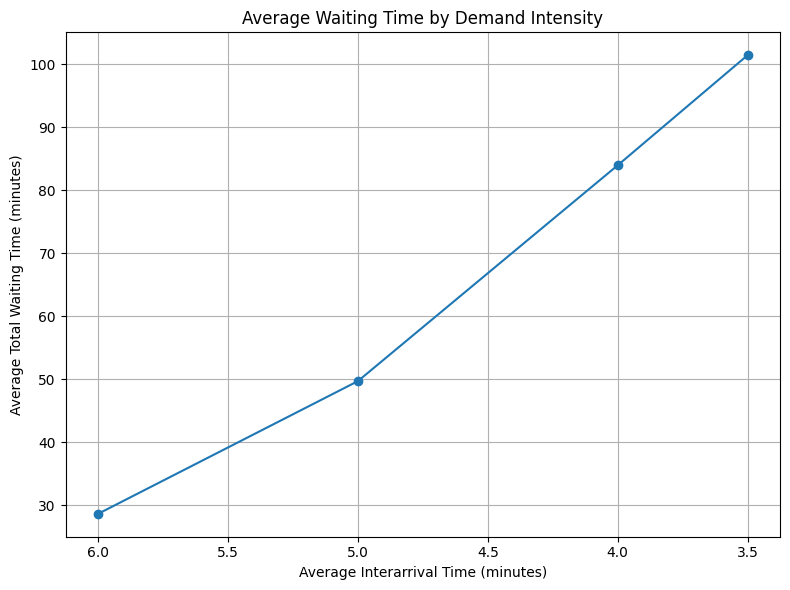

In [ ]:
# Step 10.4: Plot average total waiting time by demand intensity

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    sensitivity_summary_df["avg_interarrival_time_minutes"],
    sensitivity_summary_df["avg_total_waiting_time_mean"],
    marker="o"
)

ax.set_title("Average Waiting Time by Demand Intensity")
ax.set_xlabel("Average Interarrival Time (minutes)")
ax.set_ylabel("Average Total Waiting Time (minutes)")
ax.invert_xaxis()
ax.grid(True)

fig.tight_layout()

save_figure_both_formats(
    fig=fig,
    file_stem="06_sensitivity_waiting_time_by_demand_intensity"
)

plt.show()

PDF saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/07_sensitivity_throughput_by_demand_intensity.pdf
PNG saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/figures/07_sensitivity_throughput_by_demand_intensity.png


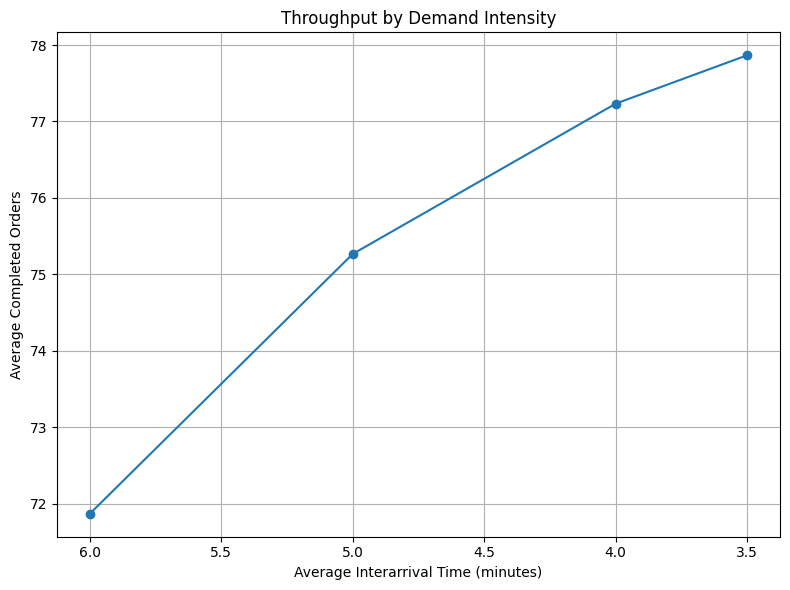

In [ ]:
# Step 10.5: Plot throughput by demand intensity

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    sensitivity_summary_df["avg_interarrival_time_minutes"],
    sensitivity_summary_df["throughput_mean"],
    marker="o"
)

ax.set_title("Throughput by Demand Intensity")
ax.set_xlabel("Average Interarrival Time (minutes)")
ax.set_ylabel("Average Completed Orders")
ax.invert_xaxis()
ax.grid(True)

fig.tight_layout()

save_figure_both_formats(
    fig=fig,
    file_stem="07_sensitivity_throughput_by_demand_intensity"
)

plt.show()

# Step 11: Organize Final Result Tables

This step creates clean final result tables for the report and GitHub Pages. The tables focus on scenario comparison, bottleneck analysis, and demand sensitivity analysis.

In [ ]:
# Step 11.1: Create final scenario comparison table

final_scenario_summary_df = scenario_key_metrics_df[
    [
        "scenario_name",
        "num_pickers",
        "num_packers",
        "num_shipping_stations",
        "throughput_mean",
        "avg_total_waiting_time_mean",
        "avg_completion_time_mean",
        "picker_utilization_mean",
        "packer_utilization_mean",
        "shipping_utilization_mean"
    ]
].copy()

# Round numeric columns for report readability
numeric_cols = final_scenario_summary_df.select_dtypes(include="number").columns
final_scenario_summary_df[numeric_cols] = final_scenario_summary_df[numeric_cols].round(3)

final_scenario_summary_path = OUTPUT_TABLES_DIR / "final_scenario_summary.csv"

final_scenario_summary_df.to_csv(
    final_scenario_summary_path,
    index=False
)

print(f"Final scenario summary saved to: {final_scenario_summary_path}")

final_scenario_summary_df

Final scenario summary saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/tables/final_scenario_summary.csv


,scenario_name,num_pickers,num_packers,num_shipping_stations,throughput_mean,avg_total_waiting_time_mean,avg_completion_time_mean,picker_utilization_mean,packer_utilization_mean,shipping_utilization_mean
0,Baseline,2,1,1,75.267,49.680,67.781,0.631,0.947,0.629
1,Add One Picker,3,1,1,76.133,49.253,67.347,0.427,0.951,0.638
2,Add One Packer,2,2,1,91.233,8.643,26.716,0.763,0.573,0.764
3,Add One Shipping Station,2,1,2,75.533,52.364,70.448,0.632,0.947,0.317
4,Balanced Capacity,3,2,1,92.733,6.737,24.755,0.520,0.575,0.772


In [ ]:
# Step 11.2: Create final bottleneck summary table

final_bottleneck_summary_df = bottleneck_summary_df[
    [
        "scenario_name",
        "max_utilization_resource",
        "max_utilization_value",
        "longest_wait_stage",
        "longest_wait_minutes",
        "throughput_change_vs_baseline",
        "waiting_time_reduction_pct_vs_baseline",
        "completion_time_reduction_pct_vs_baseline"
    ]
].copy()

# Round numeric columns for report readability
numeric_cols = final_bottleneck_summary_df.select_dtypes(include="number").columns
final_bottleneck_summary_df[numeric_cols] = final_bottleneck_summary_df[numeric_cols].round(3)

final_bottleneck_summary_path = OUTPUT_TABLES_DIR / "final_bottleneck_summary.csv"

final_bottleneck_summary_df.to_csv(
    final_bottleneck_summary_path,
    index=False
)

print(f"Final bottleneck summary saved to: {final_bottleneck_summary_path}")

final_bottleneck_summary_df

Final bottleneck summary saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/tables/final_bottleneck_summary.csv


,scenario_name,max_utilization_resource,max_utilization_value,longest_wait_stage,longest_wait_minutes,throughput_change_vs_baseline,waiting_time_reduction_pct_vs_baseline,completion_time_reduction_pct_vs_baseline
0,Baseline,Packer,0.947,Packing,42.093,0.000,0.000,0.000
1,Add One Picker,Packer,0.951,Packing,48.166,0.867,0.858,0.640
2,Add One Packer,Shipping Station,0.764,Picking,5.307,15.967,82.603,60.586
3,Add One Shipping Station,Packer,0.947,Packing,44.833,0.267,-5.403,-3.934
4,Balanced Capacity,Shipping Station,0.772,Shipping,4.967,17.467,86.439,63.478


In [ ]:
# Step 11.3: Create final sensitivity analysis table

final_sensitivity_summary_df = sensitivity_summary_df[
    [
        "scenario_name",
        "avg_interarrival_time_minutes",
        "throughput_mean",
        "avg_total_waiting_time_mean",
        "avg_completion_time_mean",
        "picker_utilization_mean",
        "packer_utilization_mean",
        "shipping_utilization_mean"
    ]
].copy()

# Round numeric columns for report readability
numeric_cols = final_sensitivity_summary_df.select_dtypes(include="number").columns
final_sensitivity_summary_df[numeric_cols] = final_sensitivity_summary_df[numeric_cols].round(3)

final_sensitivity_summary_path = OUTPUT_TABLES_DIR / "final_sensitivity_summary.csv"

final_sensitivity_summary_df.to_csv(
    final_sensitivity_summary_path,
    index=False
)

print(f"Final sensitivity summary saved to: {final_sensitivity_summary_path}")

final_sensitivity_summary_df

Final sensitivity summary saved to: /Users/mac/Desktop/portfolio3_operations_simulation/outputs/tables/final_sensitivity_summary.csv


,scenario_name,avg_interarrival_time_minutes,throughput_mean,avg_total_waiting_time_mean,avg_completion_time_mean,picker_utilization_mean,packer_utilization_mean,shipping_utilization_mean
0,Interarrival Time = 6 min,6.0,71.867,28.610,46.696,0.595,0.911,0.605
1,Interarrival Time = 5 min,5.0,75.267,49.680,67.781,0.631,0.947,0.629
2,Interarrival Time = 4 min,4.0,77.233,83.955,102.027,0.647,0.965,0.648
3,Interarrival Time = 3.5 min,3.5,77.867,101.439,119.509,0.657,0.967,0.651


In [ ]:
# Step 11.4: Check final output table files

final_table_files = [
    final_scenario_summary_path,
    final_bottleneck_summary_path,
    final_sensitivity_summary_path
]

for file_path in final_table_files:
    print(f"{file_path.name}: {file_path.exists()}")

final_scenario_summary.csv: True
final_bottleneck_summary.csv: True
final_sensitivity_summary.csv: True


# Step 12: Write README.md

This step creates the project README file for the GitHub repository. The README summarizes the research question, simulation system, methods, scenarios, key findings, limitations, and repository structure.

In [ ]:
# Step 12.1: Write README.md for the project

readme_text = r"""
# Simulation-Based Decision Support for Warehouse Operations and Bottleneck Analysis

## Project Overview

This project develops a discrete-event simulation model for a simplified warehouse order fulfillment system. The simulated system includes order arrivals, picking, packing, and shipping processes. The goal is to evaluate how different staffing and capacity policies affect waiting time, order completion time, throughput, and resource utilization.

This project is part of my Operations and Supply Chain Analytics portfolio. It demonstrates how simulation-based decision support can be used to identify bottlenecks and compare operational policies before implementing changes in a real warehouse system.

## Research Question

**How can simulation-based decision support help identify bottlenecks and evaluate operational policies in warehouse order fulfillment systems?**

## System Description

The warehouse order fulfillment process is modeled as:

Orders arrive -> Picking -> Packing -> Shipping -> Order completed

The system includes three key resources:

- Pickers
- Packers
- Shipping stations

Each order may wait before each process stage if the required resource is busy.

## Baseline System

| Parameter | Value |
|---|---:|
| Simulation time | 480 minutes |
| Average interarrival time | 5 minutes |
| Number of pickers | 2 |
| Number of packers | 1 |
| Number of shipping stations | 1 |
| Mean picking time | 8 minutes |
| Mean packing time | 6 minutes |
| Mean shipping time | 4 minutes |

## Methodology

This project uses discrete-event simulation with Python and SimPy. The simulation model represents each order as it moves through picking, packing, and shipping.

For each scenario, the model runs 30 replications with different random seeds. The results are summarized using the following performance metrics:

- Throughput
- Average waiting time
- Average order completion time
- Waiting time by process stage
- Picker utilization
- Packer utilization
- Shipping station utilization
- Bottleneck resource

## Scenario Design

The project compares five staffing and capacity scenarios:

| Scenario | Pickers | Packers | Shipping Stations |
|---|---:|---:|---:|
| Baseline | 2 | 1 | 1 |
| Add One Picker | 3 | 1 | 1 |
| Add One Packer | 2 | 2 | 1 |
| Add One Shipping Station | 2 | 1 | 2 |
| Balanced Capacity | 3 | 2 | 1 |

## Key Findings

The baseline system shows a clear bottleneck at the packing stage. Under the baseline configuration, packer utilization is approximately 0.947, and the average waiting time before packing is much higher than the waiting time before picking or shipping.

Adding one picker does not meaningfully improve system performance because the main constraint is not picking capacity. Adding one shipping station also provides little benefit because shipping is not the primary bottleneck.

Adding one packer substantially improves system performance. Compared with the baseline, this scenario reduces average total waiting time by approximately 82.6% and average completion time by approximately 60.6%.

The balanced capacity scenario achieves the strongest overall performance among the tested policies. It increases throughput and reduces both waiting time and completion time.

## Sensitivity Analysis

A demand intensity sensitivity analysis is conducted by changing the average interarrival time:

| Average Interarrival Time | Interpretation |
|---:|---|
| 6 minutes | Lower demand |
| 5 minutes | Baseline demand |
| 4 minutes | Higher demand |
| 3.5 minutes | Very high demand |

The results show that as orders arrive more frequently, average waiting time increases sharply and packer utilization remains close to full capacity. This suggests that the packing bottleneck becomes more severe under higher demand intensity.

## Repository Structure

- data/simulated/: simulated data folder
- notebooks/: Jupyter notebook for the simulation analysis
- src/: source code folder
- outputs/figures/: saved figures in PDF and PNG formats
- outputs/tables/: saved result tables
- report/: final report files
- docs/: GitHub Pages files
- README.md: project overview
- requirements.txt: Python package requirements

## Main Outputs

Final result tables are saved in:

- outputs/tables/final_scenario_summary.csv
- outputs/tables/final_bottleneck_summary.csv
- outputs/tables/final_sensitivity_summary.csv

Figures are saved in:

- outputs/figures/

Each figure is saved in both PDF and PNG formats.

## Tools and Packages

This project uses:

- Python 3.11.15
- pandas
- numpy
- matplotlib
- simpy
- Jupyter Notebook
- VS Code

## How to Run

1. Open the project folder in VS Code.
2. Activate the ops311 conda environment.
3. Open notebooks/01_warehouse_simulation.ipynb.
4. Run the notebook cells from top to bottom.

## Limitations

This project uses a simplified simulated warehouse order fulfillment system. Order arrivals and processing times are generated based on operational assumptions rather than confidential real warehouse process data.

The model does not include:

- Real warehouse layout
- Worker travel distance
- Order priority rules
- Labor cost
- Shift scheduling
- Batch picking
- Product-level differences
- Real WMS validation

Despite these limitations, the project demonstrates how discrete-event simulation can support bottleneck analysis, capacity planning, and resource allocation decisions in warehouse operations.

## Conclusion

This project shows that simulation-based decision support can help identify operational bottlenecks and compare staffing policies in warehouse order fulfillment systems. The analysis finds that the baseline system is constrained mainly by the packing stage, and that adding packing capacity is more effective than adding picking or shipping capacity.

The project supports my broader Operations and Supply Chain Analytics portfolio by demonstrating simulation-based analysis for warehouse operations, bottleneck identification, and operational decision support.
"""

readme_path = PROJECT_ROOT / "README.md"

readme_path.write_text(readme_text.strip(), encoding="utf-8")

print(f"README.md saved to: {readme_path}")

README.md saved to: /Users/mac/Desktop/portfolio3_operations_simulation/README.md


In [ ]:
# Step 12.2: Check README.md file

print(f"README exists: {readme_path.exists()}")
print(f"README path: {readme_path}")

README exists: True
README path: /Users/mac/Desktop/portfolio3_operations_simulation/README.md


# Step 13: Write Final Report

This step creates the formal project report in Markdown format. The report summarizes the simulation system, methods, scenario analysis, bottleneck findings, sensitivity analysis, limitations, and conclusion.

In [ ]:
# Step 13.1: Prepare clean report tables

def dataframe_to_markdown_table(df):
    """
    Convert a pandas DataFrame to a simple Markdown table without requiring extra packages.
    """
    df_str = df.astype(str)
    headers = list(df_str.columns)
    
    header_line = "| " + " | ".join(headers) + " |"
    separator_line = "| " + " | ".join(["---"] * len(headers)) + " |"
    
    row_lines = []
    for _, row in df_str.iterrows():
        row_line = "| " + " | ".join(row.values) + " |"
        row_lines.append(row_line)
    
    return "\n".join([header_line, separator_line] + row_lines)


report_scenario_table = final_scenario_summary_df.rename(
    columns={
        "scenario_name": "Scenario",
        "num_pickers": "Pickers",
        "num_packers": "Packers",
        "num_shipping_stations": "Shipping Stations",
        "throughput_mean": "Throughput",
        "avg_total_waiting_time_mean": "Avg Total Waiting Time",
        "avg_completion_time_mean": "Avg Completion Time",
        "picker_utilization_mean": "Picker Utilization",
        "packer_utilization_mean": "Packer Utilization",
        "shipping_utilization_mean": "Shipping Utilization"
    }
)

report_bottleneck_table = final_bottleneck_summary_df.rename(
    columns={
        "scenario_name": "Scenario",
        "max_utilization_resource": "Max Utilization Resource",
        "max_utilization_value": "Max Utilization",
        "longest_wait_stage": "Longest Wait Stage",
        "longest_wait_minutes": "Longest Wait Minutes",
        "throughput_change_vs_baseline": "Throughput Change",
        "waiting_time_reduction_pct_vs_baseline": "Waiting Time Reduction (%)",
        "completion_time_reduction_pct_vs_baseline": "Completion Time Reduction (%)"
    }
)

report_sensitivity_table = final_sensitivity_summary_df.rename(
    columns={
        "scenario_name": "Demand Scenario",
        "avg_interarrival_time_minutes": "Avg Interarrival Time",
        "throughput_mean": "Throughput",
        "avg_total_waiting_time_mean": "Avg Total Waiting Time",
        "avg_completion_time_mean": "Avg Completion Time",
        "picker_utilization_mean": "Picker Utilization",
        "packer_utilization_mean": "Packer Utilization",
        "shipping_utilization_mean": "Shipping Utilization"
    }
)

scenario_table_md = dataframe_to_markdown_table(report_scenario_table)
bottleneck_table_md = dataframe_to_markdown_table(report_bottleneck_table)
sensitivity_table_md = dataframe_to_markdown_table(report_sensitivity_table)

print("Report tables prepared successfully.")

Report tables prepared successfully.


In [ ]:
# Step 13.2: Write final_report.md

final_report_text = f"""
# Simulation-Based Decision Support for Warehouse Operations and Bottleneck Analysis

## 1. Introduction

Warehouse order fulfillment systems often involve multiple operational stages, including picking, packing, and shipping. When order arrivals exceed the processing capacity of one or more resources, queues can form and create operational bottlenecks. These bottlenecks increase waiting time, delay order completion, and reduce overall system efficiency.

This project develops a discrete-event simulation model for a simplified warehouse order fulfillment system. The goal is to evaluate how different staffing and capacity policies affect waiting time, throughput, order completion time, and resource utilization. The project demonstrates how simulation-based decision support can help identify bottlenecks and compare operational policies before making real operational changes.

This project is part of an Operations and Supply Chain Analytics portfolio. It complements previous portfolio work on demand forecasting, inventory decision-making, logistics optimization, and warehouse allocation by focusing on warehouse operations simulation and bottleneck analysis.

## 2. Research Question

The main research question is:

**How can simulation-based decision support help identify bottlenecks and evaluate operational policies in warehouse order fulfillment systems?**

This question is examined through three sub-questions:

1. Under the baseline staffing policy, which resource becomes the bottleneck in the warehouse fulfillment process?
2. How do different staffing policies affect order waiting time, completion time, throughput, and resource utilization?
3. Can simulation-based scenario analysis support better resource allocation decisions in warehouse operations?

## 3. System Description

The simulated warehouse order fulfillment process follows this sequence:

Orders arrive -> Picking -> Packing -> Shipping -> Order completed

The system includes three key resources:

- Pickers: workers responsible for picking items.
- Packers: workers responsible for packing completed orders.
- Shipping stations: stations responsible for final outbound processing.

Each order enters the system, waits if the required resource is busy, receives service at each stage, and exits after shipping is completed.

The baseline system is defined as follows:

| Parameter | Value |
|---|---:|
| Simulation time | 480 minutes |
| Average interarrival time | 5 minutes |
| Number of pickers | 2 |
| Number of packers | 1 |
| Number of shipping stations | 1 |
| Mean picking time | 8 minutes |
| Mean packing time | 6 minutes |
| Mean shipping time | 4 minutes |

Order arrivals are generated using random interarrival times. Processing times are also randomly generated around the assumed mean values. This allows the simulation to reflect operational variability rather than assuming a fully deterministic system.

## 4. Methods

This project uses discrete-event simulation with Python and SimPy. Each order is modeled as an entity moving through picking, packing, and shipping. Each resource is modeled with limited capacity. If all units of a resource are busy, the order waits in queue.

For each scenario, the simulation runs 30 replications using different random seeds. Multiple replications are used because single-run simulation results can be affected by randomness in order arrivals and processing times.

The main performance metrics are:

- Throughput: number of completed orders during the simulation horizon.
- Average waiting time: average time an order spends waiting for resources.
- Average completion time: average time from order arrival to order completion.
- Waiting time by stage: waiting time before picking, packing, and shipping.
- Resource utilization: proportion of available resource time used by each resource type.
- Bottleneck resource: resource with the highest utilization and associated waiting time.

## 5. Scenario Design

Five staffing and capacity scenarios are compared:

| Scenario | Pickers | Packers | Shipping Stations |
|---|---:|---:|---:|
| Baseline | 2 | 1 | 1 |
| Add One Picker | 3 | 1 | 1 |
| Add One Packer | 2 | 2 | 1 |
| Add One Shipping Station | 2 | 1 | 2 |
| Balanced Capacity | 3 | 2 | 1 |

The purpose of this scenario design is to compare whether adding picking, packing, or shipping capacity produces the greatest improvement in system performance.

## 6. Results

### 6.1 Scenario Comparison

The scenario comparison results are summarized below.

{scenario_table_md}

The baseline scenario completes an average of 75.267 orders during the 480-minute simulation horizon. Its average total waiting time is 49.680 minutes, and its average completion time is 67.781 minutes.

Adding one picker produces very limited improvement. Average completion time decreases only slightly from 67.781 minutes to 67.347 minutes. This suggests that picking capacity is not the main constraint under the baseline system.

Adding one packer produces a substantial improvement. Average total waiting time decreases from 49.680 minutes to 8.643 minutes, and average completion time decreases from 67.781 minutes to 26.716 minutes. Throughput also increases from 75.267 to 91.233 completed orders.

Adding one shipping station does not improve performance. Average total waiting time increases slightly to 52.364 minutes, and average completion time increases to 70.448 minutes. This suggests that shipping capacity is not the main bottleneck.

The balanced capacity scenario has the strongest overall performance among the tested scenarios. It achieves the highest throughput, the lowest average total waiting time, and the lowest average completion time.

### 6.2 Bottleneck Analysis

The bottleneck analysis results are summarized below.

{bottleneck_table_md}

The baseline scenario shows that the packer is the most heavily utilized resource, with utilization of 0.947. The longest waiting stage is packing, with an average waiting time of 42.093 minutes. This indicates that the packing stage is the main bottleneck under the baseline configuration.

The Add One Picker scenario still has packer utilization of 0.951, and the longest waiting stage remains packing. This means that adding picking capacity does not resolve the system bottleneck.

The Add One Packer scenario shifts the system away from the original packing bottleneck. Waiting time is reduced by 82.603% compared with the baseline, and completion time is reduced by 60.586%. This confirms that packing capacity is the most effective resource to improve under the baseline conditions.

The Add One Shipping Station scenario still shows the packer as the highest-utilization resource, and packing remains the longest waiting stage. This supports the conclusion that adding shipping capacity does not address the main operational constraint.

The Balanced Capacity scenario reduces average waiting time by 86.439% and completion time by 63.478% compared with the baseline. This scenario provides the strongest overall improvement among the tested policies.

### 6.3 Figures

The following figures were generated and saved in both PDF and PNG formats:

- Average completion time by scenario
- Average total waiting time by scenario
- Throughput by scenario
- Resource utilization by scenario
- Waiting time by process stage

The most important visual evidence comes from the resource utilization and waiting time by stage figures. These figures show that baseline packer utilization is close to full capacity and that packing has the highest waiting time. They also show that adding packing capacity sharply reduces waiting time.

## 7. Sensitivity Analysis

A demand intensity sensitivity analysis is conducted by changing the average interarrival time while keeping the baseline staffing configuration fixed.

The tested demand scenarios are:

| Average Interarrival Time | Interpretation |
|---:|---|
| 6 minutes | Lower demand |
| 5 minutes | Baseline demand |
| 4 minutes | Higher demand |
| 3.5 minutes | Very high demand |

The sensitivity analysis results are summarized below.

{sensitivity_table_md}

As the average interarrival time decreases from 6 minutes to 3.5 minutes, orders arrive more frequently. The results show that average total waiting time increases from 28.610 minutes to 101.439 minutes. Average completion time also increases from 46.696 minutes to 119.509 minutes.

Throughput increases only slightly, from 71.867 to 77.867 completed orders, even though demand becomes much higher. This suggests that the system reaches a capacity limit. Additional demand mainly creates longer queues rather than proportional increases in completed orders.

Packer utilization remains high across all demand levels and increases from 0.911 to 0.967. This supports the conclusion that the packing bottleneck becomes more severe as demand intensity increases.

## 8. Discussion

The simulation results provide clear operational insights. Under the baseline system, the packing stage is the main bottleneck. This is supported by both high packer utilization and high waiting time before packing.

Adding one picker does not substantially improve performance because the system is not primarily constrained by picking capacity. Similarly, adding one shipping station does not improve performance because shipping is not the main constraint.

Adding one packer creates a large improvement in waiting time, completion time, and throughput. This indicates that targeted capacity expansion at the bottleneck stage is more effective than increasing capacity at non-bottleneck stages.

The balanced capacity scenario performs best overall because it improves upstream picking capacity while also resolving the packing bottleneck. However, the results also show that after packing is improved, downstream shipping utilization becomes higher. This illustrates an important operations principle: once one bottleneck is relieved, another stage may become the next constraint.

The sensitivity analysis further shows that the baseline system becomes increasingly unstable as demand increases. When orders arrive more frequently, waiting time rises sharply while throughput increases only slightly. This suggests that the warehouse cannot absorb higher demand without additional capacity, especially at the packing stage.

## 9. Limitations

This project uses a simplified simulated warehouse order fulfillment system. Order arrivals and processing times are generated based on operational assumptions rather than confidential real warehouse process data.

The model does not include:

- Real warehouse layout
- Worker travel distance
- Order priority rules
- Labor cost
- Shift scheduling
- Batch picking
- Product-level differences
- Real WMS validation
- Learning effects or worker fatigue

Because of these simplifications, the numerical results should not be interpreted as estimates for a specific real warehouse. Instead, the project demonstrates a simulation-based decision support framework that can be extended with real operational data.

## 10. Conclusion

This project shows how discrete-event simulation can support warehouse operations decision-making. By modeling order arrivals, picking, packing, and shipping processes, the simulation identifies where queues form and which resource constrains system performance.

The baseline system is mainly constrained by the packing stage. Adding one packer reduces average waiting time and completion time much more effectively than adding a picker or shipping station. The balanced capacity scenario achieves the best overall performance among the tested policies.

The sensitivity analysis shows that as demand intensity increases, waiting time rises sharply and packer utilization remains close to full capacity. This confirms that packing capacity is a critical constraint under both baseline and high-demand conditions.

Overall, this project demonstrates how simulation-based decision support can be used for bottleneck analysis, capacity planning, and resource allocation in warehouse operations.
"""

final_report_path = PROJECT_ROOT / "report" / "final_report.md"

final_report_path.write_text(final_report_text.strip(), encoding="utf-8")

print(f"Final report saved to: {final_report_path}")

Final report saved to: /Users/mac/Desktop/portfolio3_operations_simulation/report/final_report.md


In [ ]:
# Step 13.3: Check final report file

print(f"Final report exists: {final_report_path.exists()}")
print(f"Final report path: {final_report_path}")

Final report exists: True
Final report path: /Users/mac/Desktop/portfolio3_operations_simulation/report/final_report.md


# Step 16: Create GitHub Pages Page

This step creates the GitHub Pages homepage and copies the final report and key figures into the docs/assets folder.

In [ ]:
# Step 16.1: Copy key figures and final report to docs/assets

import shutil

DOCS_DIR = PROJECT_ROOT / "docs"
DOCS_ASSETS_DIR = DOCS_DIR / "assets"

# Create docs/assets folder
DOCS_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# Files to copy into docs/assets
asset_files = [
    OUTPUT_FIGURES_DIR / "01_avg_completion_time_by_scenario.png",
    OUTPUT_FIGURES_DIR / "02_avg_waiting_time_by_scenario.png",
    OUTPUT_FIGURES_DIR / "03_throughput_by_scenario.png",
    OUTPUT_FIGURES_DIR / "04_resource_utilization_by_scenario.png",
    OUTPUT_FIGURES_DIR / "05_waiting_time_by_stage.png",
    OUTPUT_FIGURES_DIR / "06_sensitivity_waiting_time_by_demand_intensity.png",
    OUTPUT_FIGURES_DIR / "07_sensitivity_throughput_by_demand_intensity.png",
    PROJECT_ROOT / "report" / "final_report.pdf"
]

# Copy each file into docs/assets
for source_path in asset_files:
    destination_path = DOCS_ASSETS_DIR / source_path.name
    shutil.copy2(source_path, destination_path)
    print(f"Copied: {destination_path}")

Copied: /Users/mac/Desktop/portfolio3_operations_simulation/docs/assets/01_avg_completion_time_by_scenario.png
Copied: /Users/mac/Desktop/portfolio3_operations_simulation/docs/assets/02_avg_waiting_time_by_scenario.png
Copied: /Users/mac/Desktop/portfolio3_operations_simulation/docs/assets/03_throughput_by_scenario.png
Copied: /Users/mac/Desktop/portfolio3_operations_simulation/docs/assets/04_resource_utilization_by_scenario.png
Copied: /Users/mac/Desktop/portfolio3_operations_simulation/docs/assets/05_waiting_time_by_stage.png
Copied: /Users/mac/Desktop/portfolio3_operations_simulation/docs/assets/06_sensitivity_waiting_time_by_demand_intensity.png
Copied: /Users/mac/Desktop/portfolio3_operations_simulation/docs/assets/07_sensitivity_throughput_by_demand_intensity.png
Copied: /Users/mac/Desktop/portfolio3_operations_simulation/docs/assets/final_report.pdf


In [ ]:
# Step 16.2: Write GitHub Pages index.md

docs_index_lines = [
    "# Simulation-Based Decision Support for Warehouse Operations",
    "",
    "## Project Overview",
    "",
    "This project develops a discrete-event simulation model for a warehouse order fulfillment system. The simulated warehouse includes order arrivals, picking, packing, and shipping processes.",
    "",
    "The goal is to evaluate how different staffing and capacity policies affect waiting time, order completion time, throughput, and resource utilization.",
    "",
    "This project is part of my **Operations and Supply Chain Analytics** portfolio and focuses on warehouse operations simulation, bottleneck analysis, and simulation-based decision support.",
    "",
    "## Research Question",
    "",
    "**How can simulation-based decision support help identify bottlenecks and evaluate operational policies in warehouse order fulfillment systems?**",
    "",
    "## System Flow",
    "",
    "Orders arrive -> Picking -> Packing -> Shipping -> Order completed",
    "",
    "## Scenario Design",
    "",
    "The simulation compares five warehouse staffing and capacity scenarios:",
    "",
    "| Scenario | Pickers | Packers | Shipping Stations |",
    "|---|---:|---:|---:|",
    "| Baseline | 2 | 1 | 1 |",
    "| Add One Picker | 3 | 1 | 1 |",
    "| Add One Packer | 2 | 2 | 1 |",
    "| Add One Shipping Station | 2 | 1 | 2 |",
    "| Balanced Capacity | 3 | 2 | 1 |",
    "",
    "Each scenario was evaluated using 30 simulation replications.",
    "",
    "## Key Findings",
    "",
    "The baseline warehouse system shows a clear bottleneck at the packing stage. Under the baseline configuration, packer utilization is close to full capacity, and the average waiting time before packing is much higher than the waiting time before picking or shipping.",
    "",
    "Adding one picker does not meaningfully improve system performance because picking is not the main constraint. Adding one shipping station also provides little benefit because shipping is not the main bottleneck.",
    "",
    "Adding one packer substantially improves system performance by reducing waiting time and order completion time. The balanced capacity scenario achieves the strongest overall performance among the tested policies.",
    "",
    "## Key Results",
    "",
    "### Average Completion Time by Scenario",
    "",
    "![Average Completion Time by Scenario](assets/01_avg_completion_time_by_scenario.png)",
    "",
    "### Average Total Waiting Time by Scenario",
    "",
    "![Average Total Waiting Time by Scenario](assets/02_avg_waiting_time_by_scenario.png)",
    "",
    "### Throughput by Scenario",
    "",
    "![Throughput by Scenario](assets/03_throughput_by_scenario.png)",
    "",
    "### Resource Utilization by Scenario",
    "",
    "![Resource Utilization by Scenario](assets/04_resource_utilization_by_scenario.png)",
    "",
    "### Waiting Time by Process Stage",
    "",
    "![Waiting Time by Process Stage](assets/05_waiting_time_by_stage.png)",
    "",
    "## Sensitivity Analysis",
    "",
    "A demand intensity sensitivity analysis was conducted by changing the average interarrival time while keeping the baseline resource configuration fixed.",
    "",
    "The results show that as orders arrive more frequently, average waiting time increases sharply and packer utilization remains close to full capacity. This suggests that the packing bottleneck becomes more severe under higher demand intensity.",
    "",
    "### Average Waiting Time by Demand Intensity",
    "",
    "![Average Waiting Time by Demand Intensity](assets/06_sensitivity_waiting_time_by_demand_intensity.png)",
    "",
    "### Throughput by Demand Intensity",
    "",
    "![Throughput by Demand Intensity](assets/07_sensitivity_throughput_by_demand_intensity.png)",
    "",
    "## Report",
    "",
    "[Download the final report](assets/final_report.pdf)",
    "",
    "## Tools",
    "",
    "- Python",
    "- SimPy",
    "- pandas",
    "- numpy",
    "- matplotlib",
    "- Jupyter Notebook",
    "",
    "## Conclusion",
    "",
    "This project demonstrates how discrete-event simulation can support bottleneck analysis, capacity planning, and resource allocation decisions in warehouse operations.",
    "",
    "The simulation results show that the baseline system is mainly constrained by the packing stage. Adding packing capacity is more effective than adding picking or shipping capacity, and balanced resource allocation produces the strongest overall system performance."
]

docs_index_text = "\n".join(docs_index_lines)

docs_index_path = DOCS_DIR / "index.md"

docs_index_path.write_text(docs_index_text, encoding="utf-8")

print(f"GitHub Pages index saved to: {docs_index_path}")

GitHub Pages index saved to: /Users/mac/Desktop/portfolio3_operations_simulation/docs/index.md


In [ ]:
# Step 16.3: Check GitHub Pages files

docs_files_to_check = [
    DOCS_DIR / "index.md",
    DOCS_ASSETS_DIR / "final_report.pdf",
    DOCS_ASSETS_DIR / "01_avg_completion_time_by_scenario.png",
    DOCS_ASSETS_DIR / "02_avg_waiting_time_by_scenario.png",
    DOCS_ASSETS_DIR / "03_throughput_by_scenario.png",
    DOCS_ASSETS_DIR / "04_resource_utilization_by_scenario.png",
    DOCS_ASSETS_DIR / "05_waiting_time_by_stage.png",
    DOCS_ASSETS_DIR / "06_sensitivity_waiting_time_by_demand_intensity.png",
    DOCS_ASSETS_DIR / "07_sensitivity_throughput_by_demand_intensity.png"
]

for file_path in docs_files_to_check:
    print(f"{file_path.relative_to(PROJECT_ROOT)}: {file_path.exists()}")

docs/index.md: True
docs/assets/final_report.pdf: True
docs/assets/01_avg_completion_time_by_scenario.png: True
docs/assets/02_avg_waiting_time_by_scenario.png: True
docs/assets/03_throughput_by_scenario.png: True
docs/assets/04_resource_utilization_by_scenario.png: True
docs/assets/05_waiting_time_by_stage.png: True
docs/assets/06_sensitivity_waiting_time_by_demand_intensity.png: True
docs/assets/07_sensitivity_throughput_by_demand_intensity.png: True
